<a href="https://colab.research.google.com/github/shyamgadhiya/ML-DL-Tasks/blob/main/Football_Players_Analysis_and_Value_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd


In [ ]:
df = pd.read_csv('fifa21 raw data v2.csv', low_memory=False)

In [ ]:
df.head()

,ID,Name,LongName,photoUrl,playerUrl,Nationality,Age,↓OVA,POT,Club,...,A/W,D/W,IR,PAC,SHO,PAS,DRI,DEF,PHY,Hits
0,158023,L. Messi,Lionel Messi,https://cdn.sofifa.com/players/158/023/21_60.png,http://sofifa.com/player/158023/lionel-messi/2...,Argentina,33,93,93,\n\n\n\nFC Barcelona,...,Medium,Low,5 ★,85,92,91,95,38,65,771
1,20801,Cristiano Ronaldo,C. Ronaldo dos Santos Aveiro,https://cdn.sofifa.com/players/020/801/21_60.png,http://sofifa.com/player/20801/c-ronaldo-dos-s...,Portugal,35,92,92,\n\n\n\nJuventus,...,High,Low,5 ★,89,93,81,89,35,77,562
2,200389,J. Oblak,Jan Oblak,https://cdn.sofifa.com/players/200/389/21_60.png,http://sofifa.com/player/200389/jan-oblak/210006/,Slovenia,27,91,93,\n\n\n\nAtlético Madrid,...,Medium,Medium,3 ★,87,92,78,90,52,90,150
3,192985,K. De Bruyne,Kevin De Bruyne,https://cdn.sofifa.com/players/192/985/21_60.png,http://sofifa.com/player/192985/kevin-de-bruyn...,Belgium,29,91,91,\n\n\n\nManchester City,...,High,High,4 ★,76,86,93,88,64,78,207
4,190871,Neymar Jr,Neymar da Silva Santos Jr.,https://cdn.sofifa.com/players/190/871/21_60.png,http://sofifa.com/player/190871/neymar-da-silv...,Brazil,28,91,91,\n\n\n\nParis Saint-Germain,...,High,Medium,5 ★,91,85,86,94,36,59,595


In [ ]:
df.isna().sum()

,0
ID,0
Name,0
LongName,0
photoUrl,0
playerUrl,0
...,...
PAS,0
DRI,0
DEF,0
PHY,0


In [ ]:
df["ID"].duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,ID,Age,↓OVA,POT,BOV,Attacking,Crossing,Finishing,Heading Accuracy,Short Passing,...,GK Positioning,GK Reflexes,Total Stats,Base Stats,PAC,SHO,PAS,DRI,DEF,PHY
count,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,...,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000
mean,226403.384794,25.194109,65.718636,71.136414,66.751726,248.938142,49.688392,45.842405,51.942726,58.768112,...,16.217187,16.519627,1595.286949,355.702197,67.453975,53.457031,57.681016,62.875020,49.866221,64.368934
std,27141.054157,4.710520,6.968999,6.114635,6.747193,74.299428,18.131153,19.567081,17.294409,14.519106,...,17.002239,17.854079,269.874789,40.761117,10.677859,13.827425,10.081857,9.927415,16.443213,9.601883
min,41.000000,16.000000,47.000000,47.000000,48.000000,42.000000,6.000000,3.000000,5.000000,7.000000,...,2.000000,2.000000,747.000000,232.000000,25.000000,16.000000,25.000000,25.000000,12.000000,28.000000
25%,210135.000000,21.000000,61.000000,67.000000,62.000000,222.000000,38.000000,30.000000,44.000000,54.000000,...,8.000000,8.000000,1452.000000,327.000000,61.000000,44.000000,51.000000,57.000000,35.000000,58.000000
50%,232418.000000,25.000000,66.000000,71.000000,67.000000,263.000000,54.000000,49.000000,55.000000,62.000000,...,11.000000,11.000000,1627.000000,356.000000,68.000000,56.000000,58.000000,64.000000,53.000000,65.000000
75%,246922.500000,29.000000,70.000000,75.000000,71.000000,297.000000,63.000000,62.000000,64.000000,68.000000,...,14.000000,14.000000,1781.000000,384.000000,75.000000,64.000000,64.000000,69.000000,63.000000,71.000000
max,259216.000000,53.000000,93.000000,95.000000,93.000000,437.000000,94.000000,95.000000,93.000000,94.000000,...,91.000000,90.000000,2316.000000,498.000000,96.000000,93.000000,93.000000,95.000000,91.000000,91.000000


In [ ]:
df.drop(columns= ["photoUrl", "LongName", "playerUrl"], inplace= True)

In [ ]:
df.head()

,ID,Name,Nationality,Age,↓OVA,POT,Club,Contract,Positions,Height,...,A/W,D/W,IR,PAC,SHO,PAS,DRI,DEF,PHY,Hits
0,158023,L. Messi,Argentina,33,93,93,\n\n\n\nFC Barcelona,2004 ~ 2021,"RW, ST, CF",170cm,...,Medium,Low,5 ★,85,92,91,95,38,65,771
1,20801,Cristiano Ronaldo,Portugal,35,92,92,\n\n\n\nJuventus,2018 ~ 2022,"ST, LW",187cm,...,High,Low,5 ★,89,93,81,89,35,77,562
2,200389,J. Oblak,Slovenia,27,91,93,\n\n\n\nAtlético Madrid,2014 ~ 2023,GK,188cm,...,Medium,Medium,3 ★,87,92,78,90,52,90,150
3,192985,K. De Bruyne,Belgium,29,91,91,\n\n\n\nManchester City,2015 ~ 2023,"CAM, CM",181cm,...,High,High,4 ★,76,86,93,88,64,78,207
4,190871,Neymar Jr,Brazil,28,91,91,\n\n\n\nParis Saint-Germain,2017 ~ 2022,"LW, CAM",175cm,...,High,Medium,5 ★,91,85,86,94,36,59,595


In [ ]:
df= df.rename(columns={"↓OVA":"OVA"})

In [ ]:

df["Club"].head()

,Club
0,\n\n\n\nFC Barcelona
1,\n\n\n\nJuventus
2,\n\n\n\nAtlético Madrid
3,\n\n\n\nManchester City
4,\n\n\n\nParis Saint-Germain


In [ ]:
df['Club'] = (
    df['Club']
    .str.replace(r'\n+', ' ', regex=True)  # Replaces newlines with a space
    .str.replace(r'\d+', '', regex=True)   # Removes numbers (0, 1, 2...)
    .str.strip()                           # Cleans up outside edges
)
df.head()

,ID,Name,Nationality,Age,OVA,POT,Club,Contract,Positions,Height,...,A/W,D/W,IR,PAC,SHO,PAS,DRI,DEF,PHY,Hits
0,158023,L. Messi,Argentina,33,93,93,FC Barcelona,2004 ~ 2021,"RW, ST, CF",170cm,...,Medium,Low,5 ★,85,92,91,95,38,65,771
1,20801,Cristiano Ronaldo,Portugal,35,92,92,Juventus,2018 ~ 2022,"ST, LW",187cm,...,High,Low,5 ★,89,93,81,89,35,77,562
2,200389,J. Oblak,Slovenia,27,91,93,Atlético Madrid,2014 ~ 2023,GK,188cm,...,Medium,Medium,3 ★,87,92,78,90,52,90,150
3,192985,K. De Bruyne,Belgium,29,91,91,Manchester City,2015 ~ 2023,"CAM, CM",181cm,...,High,High,4 ★,76,86,93,88,64,78,207
4,190871,Neymar Jr,Brazil,28,91,91,Paris Saint-Germain,2017 ~ 2022,"LW, CAM",175cm,...,High,Medium,5 ★,91,85,86,94,36,59,595


In [ ]:
df["Height"]=df["Height"].str.strip("cm")
df["Height"].unique()

array(['170', '187', '188', '181', '175', '184', '191', '178', '193',
       '185', '199', '173', '168', '176', '177', '183', '180', '189',
       '179', '195', '172', '182', '186', '192', '165', '194', '167',
       '196', '163', '190', '174', '169', '171', '197', '200', '166',
       '6\'2"', '164', '198', '6\'3"', '6\'5"', '5\'11"', '6\'4"',
       '6\'1"', '6\'0"', '5\'10"', '5\'9"', '5\'6"', '5\'7"', '5\'4"',
       '201', '158', '162', '161', '160', '203', '157', '156', '202',
       '159', '206', '155'], dtype=object)

In [ ]:
def ft_to_cm(x):
    if "'" in x:
        ft=x.replace("'",".").replace('"',"")
        cm= round(float(ft)*30.48,0)
        return int(cm)

    else:
        return int(x)

df["Height"]=df["Height"].apply(ft_to_cm)
df["Height"].unique()

array([170, 187, 188, 181, 175, 184, 191, 178, 193, 185, 199, 173, 168,
       176, 177, 183, 180, 189, 179, 195, 172, 182, 186, 192, 165, 194,
       167, 196, 163, 190, 174, 169, 171, 197, 200, 166, 164, 198, 156,
       155, 201, 158, 162, 161, 160, 203, 157, 202, 159, 206])

In [ ]:
df["Weight"]=df["Weight"].str.strip("kg")
df["Weight"].unique()

array(['72', '83', '87', '70', '68', '80', '71', '91', '73', '85', '92',
       '69', '84', '96', '81', '82', '75', '86', '89', '74', '76', '64',
       '78', '90', '66', '60', '94', '79', '67', '65', '59', '61', '93',
       '88', '97', '77', '62', '63', '95', '100', '58', '183lbs',
       '179lbs', '172lbs', '196lbs', '176lbs', '185lbs', '170lbs',
       '203lbs', '168lbs', '161lbs', '146lbs', '130lbs', '190lbs',
       '174lbs', '148lbs', '165lbs', '159lbs', '192lbs', '181lbs',
       '139lbs', '154lbs', '157lbs', '163lbs', '98', '103', '99', '102',
       '56', '101', '57', '55', '104', '107', '110', '53', '50', '54',
       '52'], dtype=object)

In [ ]:
def lbs_to_kg(x):
    if "lbs" in x:
        lbs = x.replace("lbs", "")
        kilograms = round(int(lbs) / 2.2, 0)
        return int(kilograms)
    else:
        return int(x)


df["Weight"]=df["Weight"].apply(lbs_to_kg)
df["Weight"].unique()

array([ 72,  83,  87,  70,  68,  80,  71,  91,  73,  85,  92,  69,  84,
        96,  81,  82,  75,  86,  89,  74,  76,  64,  78,  90,  66,  60,
        94,  79,  67,  65,  59,  61,  93,  88,  97,  77,  62,  63,  95,
       100,  58,  98, 103,  99, 102,  56, 101,  57,  55, 104, 107, 110,
        53,  50,  54,  52])

In [ ]:
# This removes any spaces from the beginning and end of all column names
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['ID', 'Name', 'Nationality', 'Age', 'OVA', 'POT', 'Club', 'Contract', 'Positions', 'Height', 'Weight', 'Preferred Foot', 'BOV', 'Best Position', 'Joined', 'Loan Date End', 'Values in Euro Million', 'Wage in Euros', 'Release Clause in Euro Million', 'Attacking', 'Crossing', 'Finishing', 'Heading Accuracy', 'Short Passing', 'Volleys', 'Skill', 'Dribbling', 'Curve', 'FK Accuracy', 'Long Passing', 'Ball Control', 'Movement', 'Acceleration', 'Sprint Speed', 'Agility', 'Reactions', 'Balance', 'Power', 'Shot Power', 'Jumping', 'Stamina', 'Strength', 'Long Shots', 'Mentality', 'Aggression', 'Interceptions', 'Positioning', 'Vision', 'Penalties', 'Composure', 'Defending', 'Marking', 'Standing Tackle', 'Sliding Tackle', 'Goalkeeping', 'GK Diving', 'GK Handling', 'GK Kicking', 'GK Positioning', 'GK Reflexes', 'Total Stats', 'Base Stats', 'W/F', 'SM', 'A/W', 'D/W', 'IR', 'PAC', 'SHO', 'PAS', 'DRI', 'DEF', 'PHY', 'Hits']


In [ ]:
def parse_currency(value_str):
    # Handle missing/NaN values gracefully
    if pd.isna(value_str):
        return value_str

    # Ensure it's a string, then remove the Euro symbol and any extra spaces
    value_str = str(value_str).replace('€', '').strip()

    # Determine the multiplier based on the suffix ('M' or 'K')
    if 'M' in value_str:
        multiplier = 1_000_000
        value_str = value_str.replace('M', '')
    elif 'K' in value_str:
        multiplier = 1_000
        value_str = value_str.replace('K', '')
    else:
        multiplier = 1  # For flat numbers with no suffix

    # Convert the remaining text to a float and apply the multiplier
    return float(value_str) * multiplier

# List the columns you want to convert
columns_to_convert = ['Values in Euro Million', 'Wage in Euros', 'Release Clause in Euro Million']

# Apply the function to each column in your DataFrame
for col in columns_to_convert:
    df[col] = df[col].apply(parse_currency)
df[['Values in Euro Million', 'Wage in Euros', 'Release Clause in Euro Million']].head()

,Values in Euro Million,Wage in Euros,Release Clause in Euro Million
0,103500000.0,560000.0,138400000.0
1,63000000.0,220000.0,75900000.0
2,120000000.0,125000.0,159400000.0
3,129000000.0,370000.0,161000000.0
4,132000000.0,270000.0,166500000.0


In [ ]:
df[['W/F','SM','IR']].head()
df["W/F"]=df["W/F"].str.replace("★","")
df["SM"]=df["SM"].str.replace("★","")
df["IR"]=df["IR"].str.replace("★","")

df.rename(columns={'W/F':'W/F Rating','SM':'SM Rating','IR':'IR Rating'},inplace =True)
df[['W/F Rating','SM Rating','IR Rating']].head()

,W/F Rating,SM Rating,IR Rating
0,4,4,5
1,4,5,5
2,3,1,3
3,5,4,4
4,5,5,5


In [ ]:
df.head()

,ID,Name,Nationality,Age,OVA,POT,Club,Contract,Positions,Height,...,A/W,D/W,IR Rating,PAC,SHO,PAS,DRI,DEF,PHY,Hits
0,158023,L. Messi,Argentina,33,93,93,FC Barcelona,2004 ~ 2021,"RW, ST, CF",170,...,Medium,Low,5,85,92,91,95,38,65,771
1,20801,Cristiano Ronaldo,Portugal,35,92,92,Juventus,2018 ~ 2022,"ST, LW",187,...,High,Low,5,89,93,81,89,35,77,562
2,200389,J. Oblak,Slovenia,27,91,93,Atlético Madrid,2014 ~ 2023,GK,188,...,Medium,Medium,3,87,92,78,90,52,90,150
3,192985,K. De Bruyne,Belgium,29,91,91,Manchester City,2015 ~ 2023,"CAM, CM",181,...,High,High,4,76,86,93,88,64,78,207
4,190871,Neymar Jr,Brazil,28,91,91,Paris Saint-Germain,2017 ~ 2022,"LW, CAM",175,...,High,Medium,5,91,85,86,94,36,59,595


In [ ]:
df.Contract.unique()

array(['2004 ~ 2021', '2018 ~ 2022', '2014 ~ 2023', '2015 ~ 2023',
       '2017 ~ 2022', '2017 ~ 2023', '2018 ~ 2024', '2014 ~ 2022',
       '2018 ~ 2023', '2016 ~ 2023', '2013 ~ 2023', '2011 ~ 2023',
       '2009 ~ 2022', '2005 ~ 2021', '2011 ~ 2021', '2015 ~ 2022',
       '2017 ~ 2024', '2010 ~ 2024', '2012 ~ 2021', '2019 ~ 2024',
       '2015 ~ 2024', '2017 ~ 2025', '2020 ~ 2025', '2019 ~ 2023',
       '2008 ~ 2023', '2015 ~ 2021', '2020 ~ 2022', '2012 ~ 2022',
       '2016 ~ 2025', '2013 ~ 2022', '2011 ~ 2022', '2012 ~ 2024',
       '2016 ~ 2021', '2012 ~ 2023', '2008 ~ 2022', '2019 ~ 2022',
       '2017 ~ 2021', '2013 ~ 2024', '2020 ~ 2024', '2010 ~ 2022',
       '2020 ~ 2021', '2011 ~ 2024', '2020 ~ 2023', '2014 ~ 2024',
       '2013 ~ 2026', '2016 ~ 2022', '2010 ~ 2021', '2013 ~ 2021',
       '2019 ~ 2025', '2018 ~ 2025', '2016 ~ 2024', '2018 ~ 2021',
       '2009 ~ 2024', '2007 ~ 2022', 'Jun 30, 2021 On Loan',
       '2009 ~ 2021', '2019 ~ 2021', '2019 ~ 2026', 'Free', '2012 ~ 

In [ ]:
import re
def parse_contract(contract_string):
    # 1. Handle 'Free' contracts
    if contract_string == 'Free':
        return pd.Series(['Free', np.nan, np.nan])

    # 2. Handle 'On Loan' contracts
    elif 'On Loan' in contract_string:
        # Search for any 4-digit number (the year) in the string
        year_match = re.search(r'\d{4}', contract_string)
        start_year = year_match.group() if year_match else np.nan
        return pd.Series(['On Loan', start_year, np.nan])

    # 3. Handle standard 'YYYY ~ YYYY' contracts
    elif '~' in contract_string:
        # Simply split the string at the tilde
        parts = contract_string.split('~')
        start_year = parts[0].strip()  # .strip() removes any surrounding spaces
        end_year = parts[1].strip()
        return pd.Series(['Contract', start_year, end_year])

    # 4. Fallback for any weird data
    else:
        return pd.Series(['Unknown', np.nan, np.nan])

# Apply the function to create all three columns at exactly the same time
df[['Contract Type', 'Start Year', 'End Year']] = df['Contract'].apply(parse_contract)

# View the results
print(df[['Contract', 'Contract Type', 'Start Year', 'End Year']].head(10))

      Contract Contract Type Start Year End Year
0  2004 ~ 2021      Contract       2004     2021
1  2018 ~ 2022      Contract       2018     2022
2  2014 ~ 2023      Contract       2014     2023
3  2015 ~ 2023      Contract       2015     2023
4  2017 ~ 2022      Contract       2017     2022
5  2014 ~ 2023      Contract       2014     2023
6  2017 ~ 2023      Contract       2017     2023
7  2018 ~ 2024      Contract       2018     2024
8  2018 ~ 2022      Contract       2018     2022
9  2014 ~ 2022      Contract       2014     2022


In [ ]:
df[['Contract Type','Start Year','End Year']].head()

,Contract Type,Start Year,End Year
0,Contract,2004,2021
1,Contract,2018,2022
2,Contract,2014,2023
3,Contract,2015,2023
4,Contract,2017,2022


In [ ]:
df.head()

,ID,Name,Nationality,Age,OVA,POT,Club,Contract,Positions,Height,...,PAC,SHO,PAS,DRI,DEF,PHY,Hits,Contract Type,Start Year,End Year
0,158023,L. Messi,Argentina,33,93,93,FC Barcelona,2004 ~ 2021,"RW, ST, CF",170,...,85,92,91,95,38,65,771,Contract,2004,2021
1,20801,Cristiano Ronaldo,Portugal,35,92,92,Juventus,2018 ~ 2022,"ST, LW",187,...,89,93,81,89,35,77,562,Contract,2018,2022
2,200389,J. Oblak,Slovenia,27,91,93,Atlético Madrid,2014 ~ 2023,GK,188,...,87,92,78,90,52,90,150,Contract,2014,2023
3,192985,K. De Bruyne,Belgium,29,91,91,Manchester City,2015 ~ 2023,"CAM, CM",181,...,76,86,93,88,64,78,207,Contract,2015,2023
4,190871,Neymar Jr,Brazil,28,91,91,Paris Saint-Germain,2017 ~ 2022,"LW, CAM",175,...,91,85,86,94,36,59,595,Contract,2017,2022


In [ ]:
df.columns

Index(['ID', 'Name', 'Nationality', 'Age', 'OVA', 'POT', 'Club', 'Contract',
       'Positions', 'Height', 'Weight', 'Preferred Foot', 'BOV',
       'Best Position', 'Joined', 'Loan Date End', 'Values in Euro Million',
       'Wage in Euros', 'Release Clause in Euro Million', 'Attacking',
       'Crossing', 'Finishing', 'Heading Accuracy', 'Short Passing', 'Volleys',
       'Skill', 'Dribbling', 'Curve', 'FK Accuracy', 'Long Passing',
       'Ball Control', 'Movement', 'Acceleration', 'Sprint Speed', 'Agility',
       'Reactions', 'Balance', 'Power', 'Shot Power', 'Jumping', 'Stamina',
       'Strength', 'Long Shots', 'Mentality', 'Aggression', 'Interceptions',
       'Positioning', 'Vision', 'Penalties', 'Composure', 'Defending',
       'Marking', 'Standing Tackle', 'Sliding Tackle', 'Goalkeeping',
       'GK Diving', 'GK Handling', 'GK Kicking', 'GK Positioning',
       'GK Reflexes', 'Total Stats', 'Base Stats', 'W/F Rating', 'SM Rating',
       'A/W', 'D/W', 'IR Rating', 'PAC', 'SH

In [ ]:
df = df.drop(columns = ["Loan Date End","Contract"])

In [ ]:
df.head()

,ID,Name,Nationality,Age,OVA,POT,Club,Positions,Height,Weight,...,PAC,SHO,PAS,DRI,DEF,PHY,Hits,Contract Type,Start Year,End Year
0,158023,L. Messi,Argentina,33,93,93,FC Barcelona,"RW, ST, CF",170,72,...,85,92,91,95,38,65,771,Contract,2004,2021
1,20801,Cristiano Ronaldo,Portugal,35,92,92,Juventus,"ST, LW",187,83,...,89,93,81,89,35,77,562,Contract,2018,2022
2,200389,J. Oblak,Slovenia,27,91,93,Atlético Madrid,GK,188,87,...,87,92,78,90,52,90,150,Contract,2014,2023
3,192985,K. De Bruyne,Belgium,29,91,91,Manchester City,"CAM, CM",181,70,...,76,86,93,88,64,78,207,Contract,2015,2023
4,190871,Neymar Jr,Brazil,28,91,91,Paris Saint-Germain,"LW, CAM",175,68,...,91,85,86,94,36,59,595,Contract,2017,2022


Data Analysis

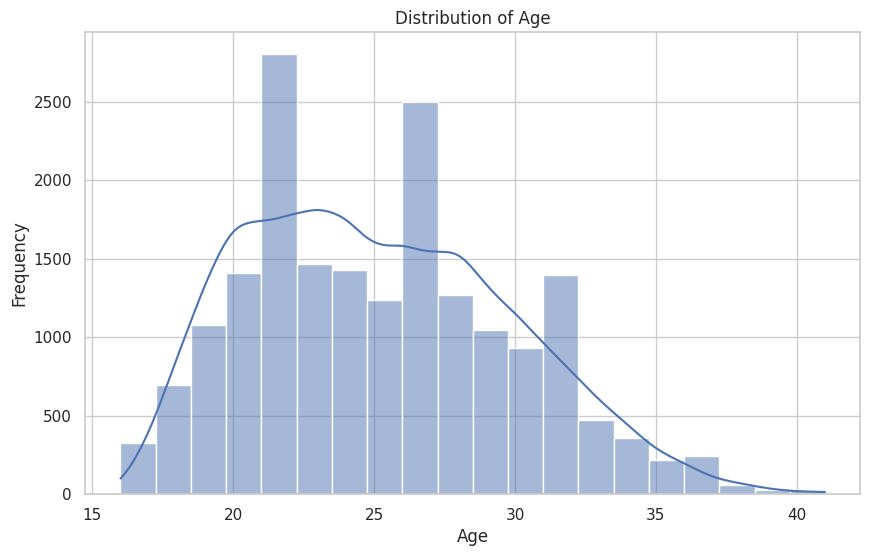

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# Histogram for Age
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()



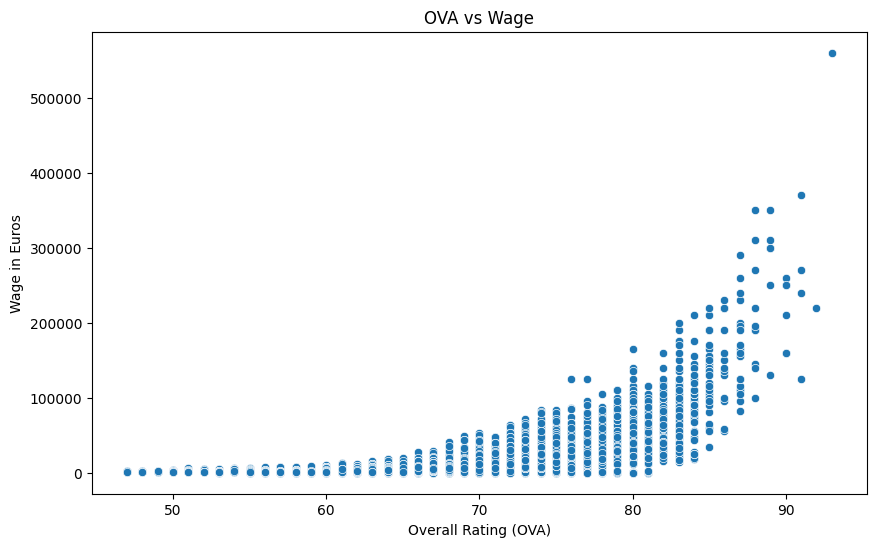

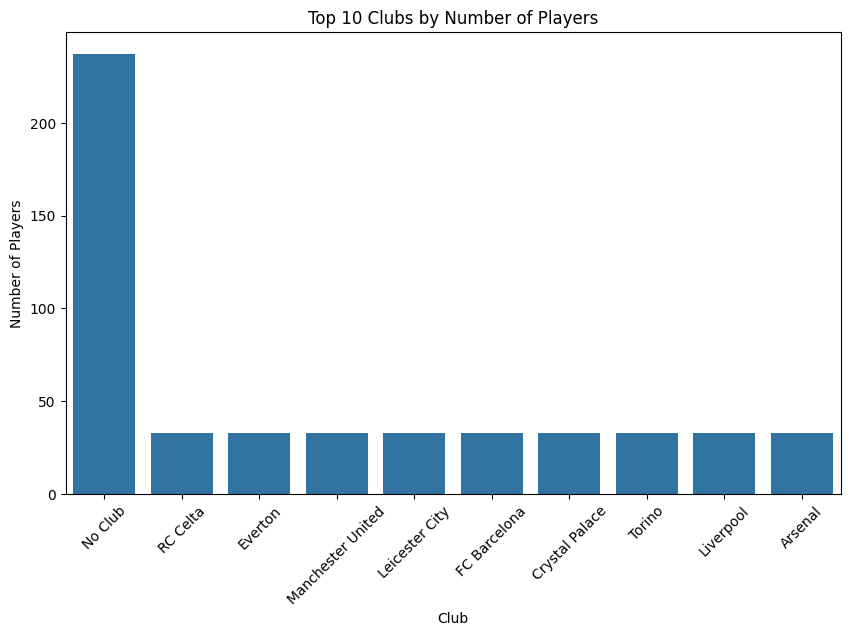

In [ ]:
# Scatter plot between OVA and Wage
plt.figure(figsize=(10, 6))
sns.scatterplot(x='OVA', y='Wage in Euros', data=df)
plt.title('OVA vs Wage')
plt.xlabel('Overall Rating (OVA)')
plt.ylabel('Wage in Euros')
plt.show()

# Bar plot for Number of Players per Club
club_counts = df['Club'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=club_counts.index, y=club_counts.values)
plt.xticks(rotation=45)
plt.title('Top 10 Clubs by Number of Players')
plt.xlabel('Club')
plt.ylabel('Number of Players')
plt.show()

Text(0.5, 1.0, 'Player Potential vs Age')

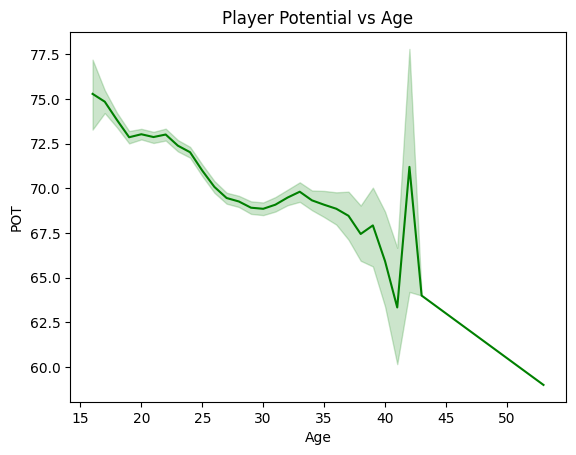

In [ ]:
sns.lineplot(x=df['Age'],y=df['POT'],color='green')
plt.title('Player Potential vs Age')

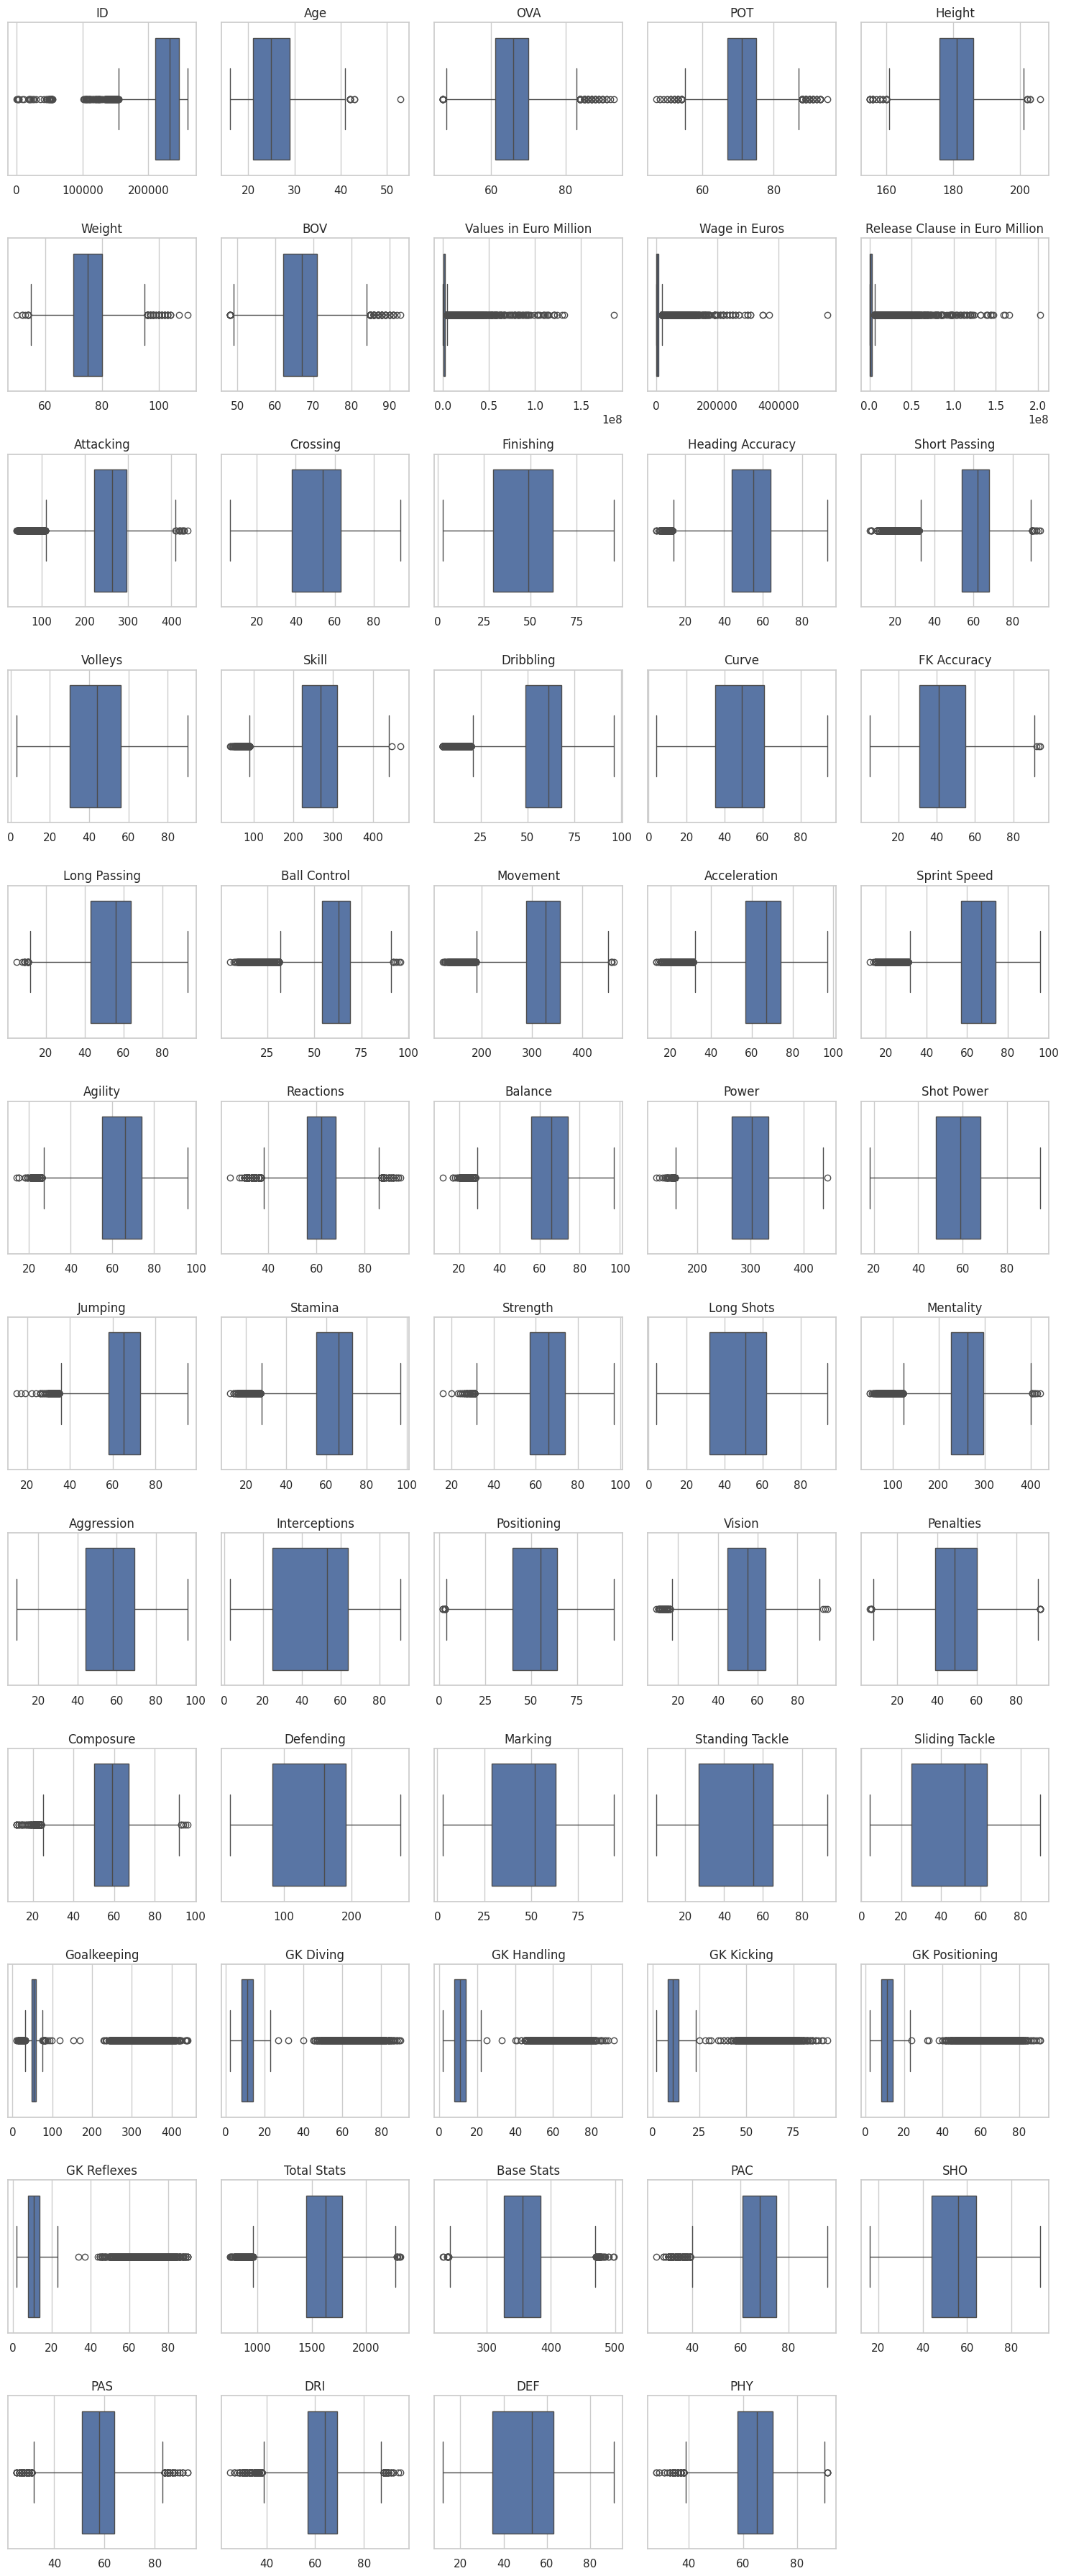

In [ ]:
sns.set(style="whitegrid")

numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

num_columns = 5
num_rows = (len(numerical_columns) + num_columns - 1) // num_columns

plt.figure(figsize=(num_columns * 3, num_rows * 3))

for i, column in enumerate(numerical_columns, 1):
    plt.subplot(num_rows, num_columns, i)
    sns.boxplot(x=df[column])
    plt.title(column)
    plt.xlabel('')

plt.tight_layout()
plt.show()


In [ ]:
def handle_outliers_iqr(df, multiplier=1.5):
    numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

    for column in numerical_columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - multiplier * IQR
        upper_bound = Q3 + multiplier * IQR

        outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
        #print(f"Outliers detected in '{column}': {outliers.index.tolist()}")

        df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
        df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])

    return df

df = handle_outliers_iqr(df, multiplier=1.5)

for column in df.select_dtypes(include=['float64', 'int64']).columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    remaining_outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    if not remaining_outliers.empty:
        print(f"Remaining outliers in '{column}': {remaining_outliers.index.tolist()}")
    else:
        print(f"No remaining outliers in '{column}'.")



No remaining outliers in 'ID'.
No remaining outliers in 'Age'.
No remaining outliers in 'OVA'.
No remaining outliers in 'POT'.
No remaining outliers in 'Height'.
No remaining outliers in 'Weight'.
No remaining outliers in 'BOV'.
No remaining outliers in 'Values in Euro Million'.
No remaining outliers in 'Wage in Euros'.
No remaining outliers in 'Release Clause in Euro Million'.
No remaining outliers in 'Attacking'.
No remaining outliers in 'Crossing'.
No remaining outliers in 'Finishing'.
No remaining outliers in 'Heading Accuracy'.
No remaining outliers in 'Short Passing'.
No remaining outliers in 'Volleys'.
No remaining outliers in 'Skill'.
No remaining outliers in 'Dribbling'.
No remaining outliers in 'Curve'.
No remaining outliers in 'FK Accuracy'.
No remaining outliers in 'Long Passing'.
No remaining outliers in 'Ball Control'.
No remaining outliers in 'Movement'.
No remaining outliers in 'Acceleration'.
No remaining outliers in 'Sprint Speed'.
No remaining outliers in 'Agility'.


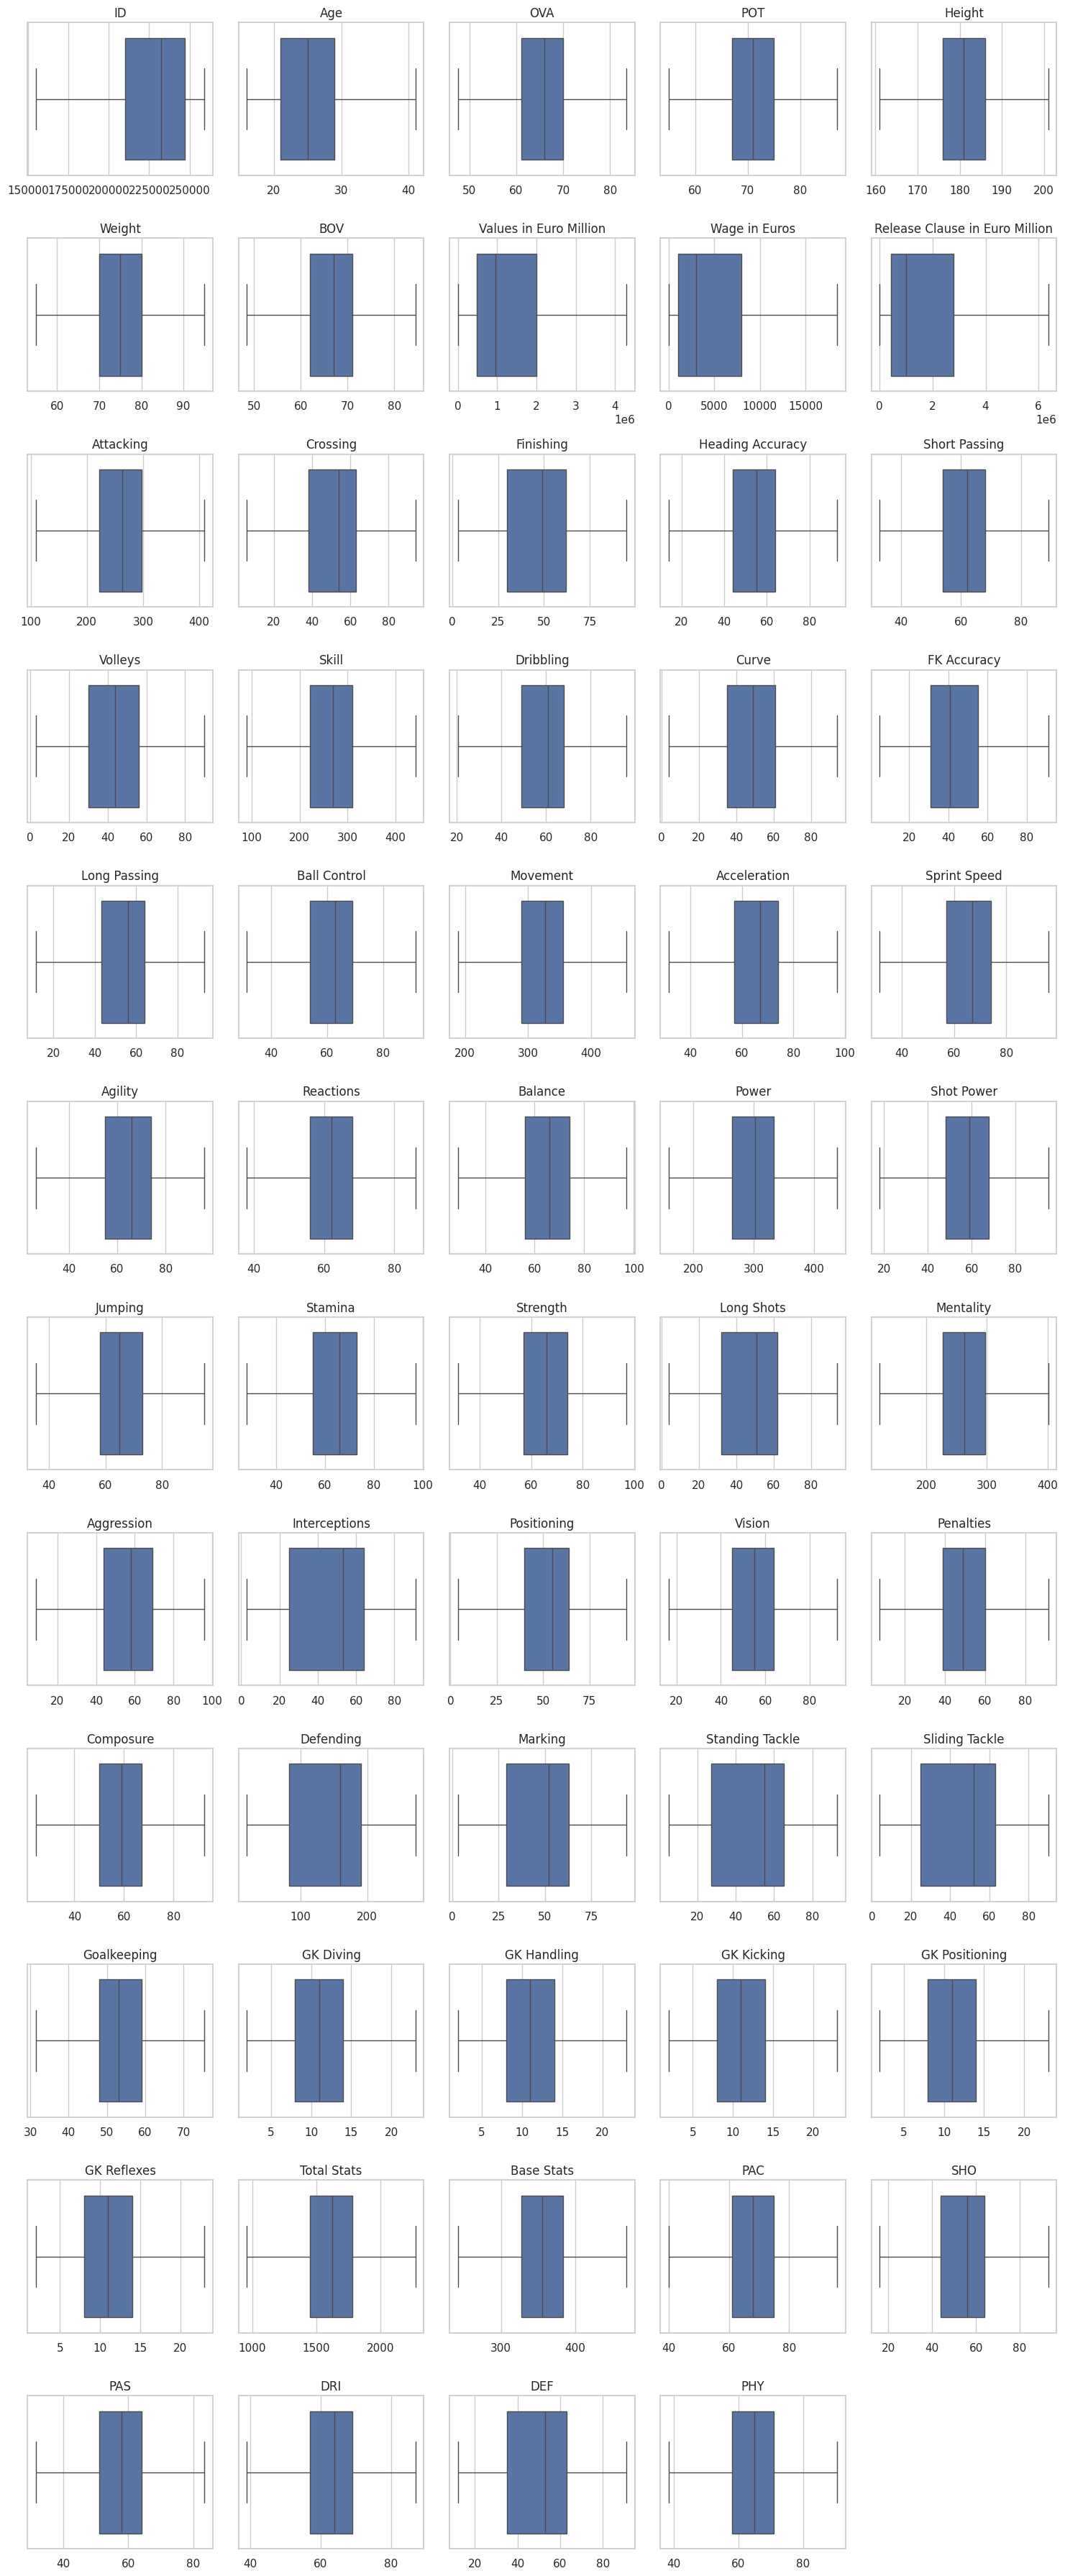

In [ ]:
sns.set(style="whitegrid")

numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

num_columns = 5
num_rows = (len(numerical_columns) + num_columns - 1) // num_columns  # Round up division

plt.figure(figsize=(num_columns * 3, num_rows * 3))  # Adjust size based on number of plots

for i, column in enumerate(numerical_columns, 1):
    plt.subplot(num_rows, num_columns, i)
    sns.boxplot(x=df[column])
    plt.title(column)
    plt.xlabel('')

plt.tight_layout()
plt.show()

In [ ]:
df['POT_OVA_Diff'] = df['POT'] - df['OVA']

highest_potential_difference = df.sort_values(by='POT_OVA_Diff', ascending=False).head(10)
display(highest_potential_difference[['Name', 'Club', 'OVA', 'POT', 'POT_OVA_Diff', 'Age']])

,Name,Club,OVA,POT,POT_OVA_Diff,Age
18147,A. Hajdari,FC Basel,53.0,79.0,26.0,17.0
14954,B. Arrey-Mbi,Bayern München II,60.0,86.0,26.0,17.0
17900,R. Richards,West Bromwich Albion,54.0,80.0,26.0,16.0
18191,S. Auklend,Viking FK,53.0,78.0,25.0,17.0
16387,W. Faghir,Vejle Boldklub,58.0,83.0,25.0,16.0
18673,T. Gulliksen,Strømsgodset IF,51.0,76.0,25.0,16.0
16239,O. Babuscu,FC Admira Wacker Mödling,58.0,83.0,25.0,16.0
17192,D. Leyva,Seattle Sounders FC,56.0,81.0,25.0,17.0
15971,C. Riad,CE Sabadell FC,59.0,84.0,25.0,17.0
18703,S. Tangvik,Rosenborg BK,51.0,75.0,24.0,17.0


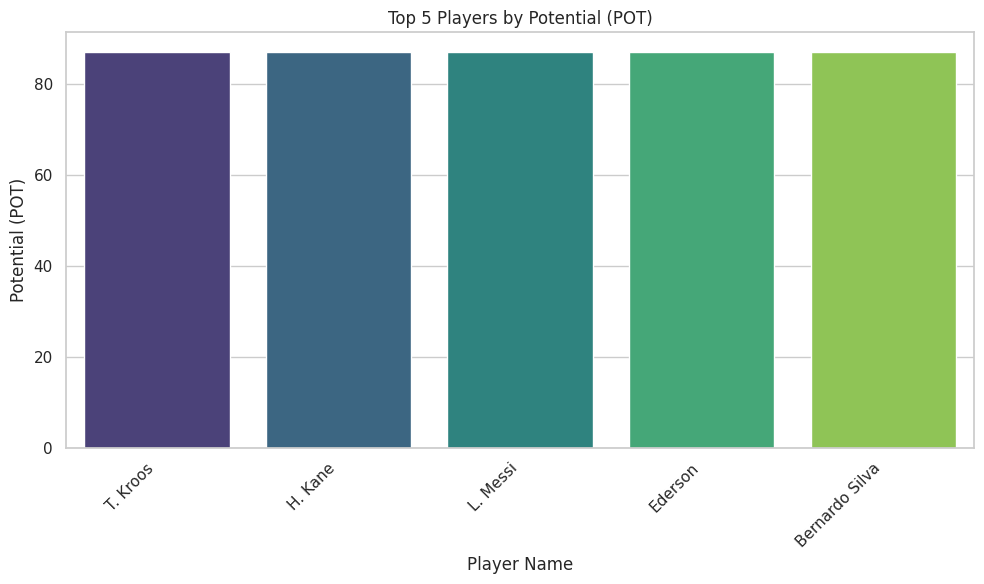

In [ ]:
top_5_potential = df.sort_values(by='POT', ascending=False).head(5)

plt.figure(figsize=(10, 6))
sns.barplot(x='Name', y='POT', data=top_5_potential, hue='Name', palette='viridis', legend=False)
plt.title('Top 5 Players by Potential (POT)')
plt.xlabel('Player Name')
plt.ylabel('Potential (POT)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Problem Statement**
* Identify and plot the top 10 most frequent playing positions represented among the top 100 players by overall rating.

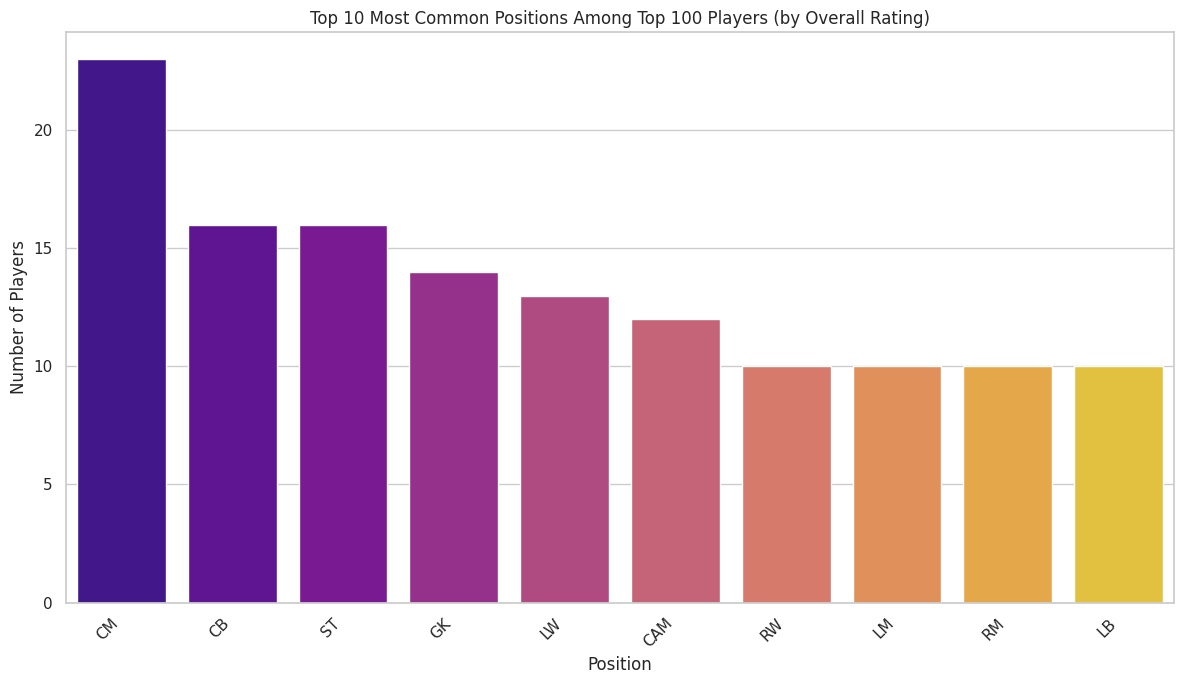

In [ ]:
top_100_players = df.sort_values(by='OVA', ascending=False).head(100)

# Handle multiple positions per player by splitting and stacking
all_positions = top_100_players['Positions'].str.split(', ').explode()

# Count the occurrences of each position
position_counts = all_positions.value_counts().head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x=position_counts.index, y=position_counts.values, hue=position_counts.index, palette='plasma', legend=False)
plt.title('Top 10 Most Common Positions Among Top 100 Players (by Overall Rating)')
plt.xlabel('Position')
plt.ylabel('Number of Players')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Key Takeways**

*  Central Midfielders (CM) are common position among the Top 100 players. This shows that the game highly values the diverse, all-around skill set required to control the middle of the pitch.  
*  It is statistically much harder to reach an elite Top 100 rating list as a
wide player. Positions on the outside of the pitch, like Wingers Left Mid fielder(LM), Right Midfielder(RM) and Fullbacks (LB).


**Problem Statement**
* Visualize the correlation between Age and Overall Rating (OVA) using a scatter plot, encoding the player's Potential (POT) as the marker size.

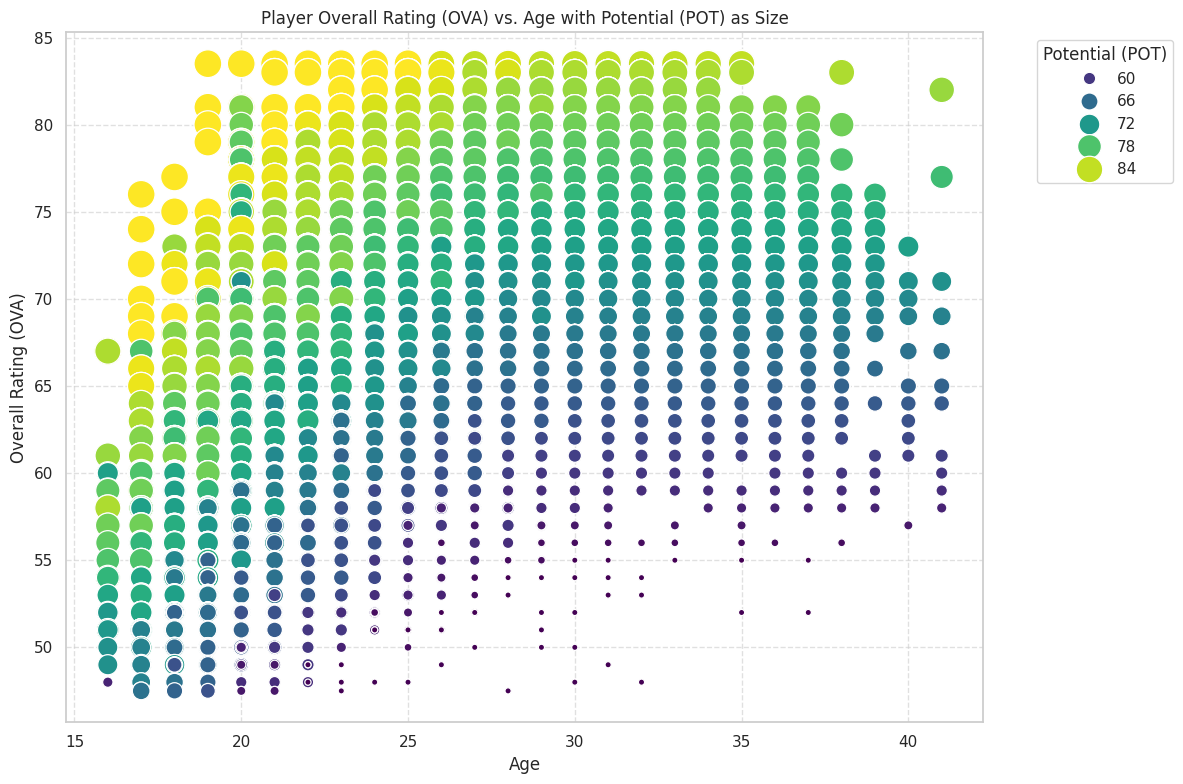

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Age', y='OVA', size='POT', sizes=(20, 400), hue='POT', palette='viridis', data=df)
plt.title('Player Overall Rating (OVA) vs. Age with Potential (POT) as Size')
plt.xlabel('Age')
plt.ylabel('Overall Rating (OVA)')
plt.legend(title='Potential (POT)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Key Takeaways**

* Youth Equals Massive Growth: The youngest players (ages 16–22) typically have lower current ratings, but they hold the highest potential in the game (shown by the large yellow circles). These are your future stars.

* The "Prime" Years are 25 to 30: Players generally hit their absolute peak in their mid-to-late twenties. The highest current overall ratings on the graph are densely clustered right in this age bracket.

**Problem Statement**
* Visualize the top 10 countries with the most football players ranked in the global top 100 by overall value

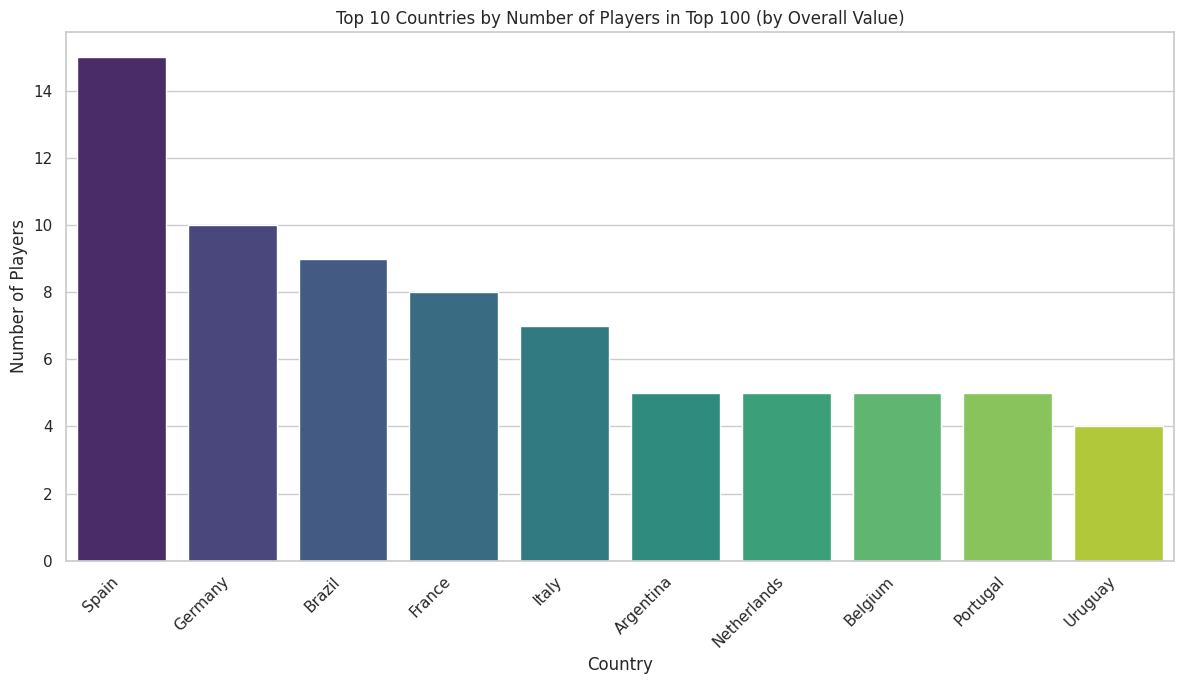

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the top 100 players by OVA
top_100_players = df.sort_values(by='OVA', ascending=False).head(100)

# Count the occurrences of each nationality in the top 100 players
nationality_counts = top_100_players['Nationality'].value_counts().head(10)

# Create a bar plot
plt.figure(figsize=(12, 7))
sns.barplot(x=nationality_counts.index, y=nationality_counts.values, hue=nationality_counts.index, palette='viridis', legend=False)
plt.title('Top 10 Countries by Number of Players in Top 100 (by Overall Value)')
plt.xlabel('Country')
plt.ylabel('Number of Players')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Key Takeaways**

* Spain is the football Leader: Spain stands far above the rest of the world, producing 15 of the top 100 elite players. They have a significant lead over every other nation on the list.

* European Dominance: The very top tier of football is heavily dominated by European nations. Seven of the top ten countries on this list are from Europe (Spain, Germany, France, Italy, Netherlands, Belgium, and Portugal).

**Problem Statement**
* Develop a world map visualization that displays the global distribution of football players, indicating the total number of players originating from each country.

In [ ]:
import plotly.express as px

nationality_counts = df['Nationality'].value_counts().reset_index()
nationality_counts.columns = ['Nationality', 'Count']

fig = px.choropleth(
    data_frame=nationality_counts,
    locations='Nationality',
    locationmode='country names',
    color='Nationality',
    hover_name='Nationality',
    hover_data={'Count': True},
    scope='world',
    title='Player Count by Nationality'
)

fig.show()

**Problem Statement**
* Compare Skills and Performance between Messi and Ronaldo.

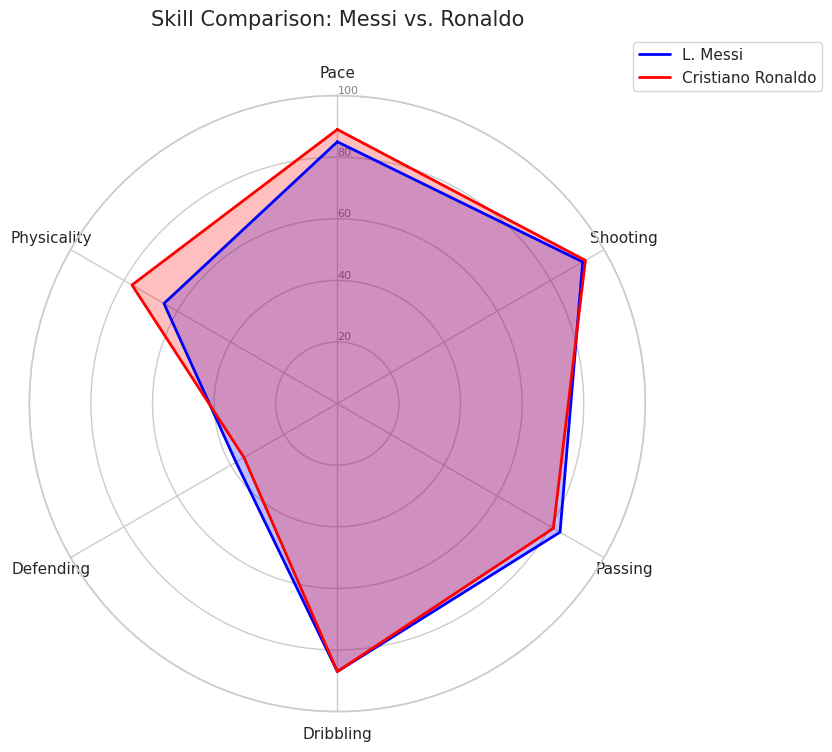

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Filter for Messi and Ronaldo
comparison_df = df[df['Name'].isin(['L. Messi', 'Cristiano Ronaldo'])].copy()

# 2. Define the attributes and their full names
attr_map = {
    'PAC': 'Pace',
    'SHO': 'Shooting',
    'PAS': 'Passing',
    'DRI': 'Dribbling',
    'DEF': 'Defending',
    'PHY': 'Physicality'
}
attributes = list(attr_map.keys())
labels = list(attr_map.values())
num_vars = len(attributes)

# 3. Create the radar chart angles
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1] # Close the circle

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Helper function to plot individual player data
def add_to_radar(player_name, color):
    values = comparison_df[comparison_df['Name'] == player_name][attributes].values.flatten().tolist()
    values += values[:1] # Close the circle
    ax.plot(angles, values, color=color, linewidth=2, label=player_name)
    ax.fill(angles, values, color=color, alpha=0.25)

# 4. Add Messi and Ronaldo to the plot
add_to_radar('L. Messi', 'blue')
add_to_radar('Cristiano Ronaldo', 'red')

# 5. Fix the labels and appearance
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# Use full labels instead of abbreviations
plt.xticks(angles[:-1], labels)
ax.set_rlabel_position(0)
plt.yticks([20, 40, 60, 80, 100], ["20", "40", "60", "80", "100"], color="grey", size=8)
plt.ylim(0, 100)

plt.title('Skill Comparison: Messi vs. Ronaldo', size=15, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

**Key Takeaways**

* Ronaldo's Physical Advantage: Cristiano Ronaldo (the red line) holds a very clear advantage in Physicality and a slight edge in Pace. He is the more athletically dominant player in this comparison.
* When it comes to attacking the goal, they are virtually identical. Both players are tied at the absolute highest levels for both Shooting and Dribbling.

**Problem Statement**
* Derive Body Mass Index (BMI) metrics for the entire player cohort to statistically compare the physical profiles of the top 100 players against all other players.


/tmp/ipykernel_894/2657794705.py:17: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




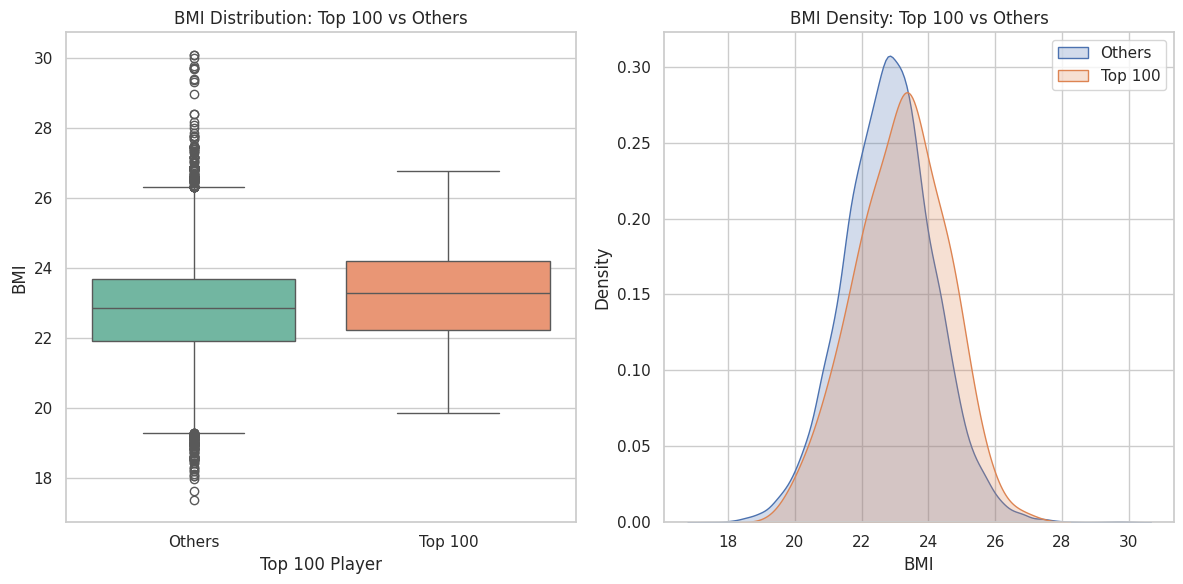

Summary Statistics for BMI:
              count  mean  std   min   25%   50%   75%   max
Is Top 100                                                  
False      18837.00 22.82 1.36 17.36 21.91 22.84 23.67 30.09
True         142.00 23.17 1.34 19.84 22.22 23.28 24.20 26.75


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate BMI: weight (kg) / [height (m)]^2
df['BMI'] = df['Weight'] / ((df['Height'] / 100) ** 2)

# 2. Identify the Top 100 players by Overall Rating (OVA)
top_100_threshold = df['OVA'].nlargest(100).min()
df['Is Top 100'] = df['OVA'] >= top_100_threshold

# 3. Visualization
plt.figure(figsize=(12, 6))

# Boxplot for distribution comparison
plt.subplot(1, 2, 1)
sns.boxplot(x='Is Top 100', y='BMI', data=df, palette='Set2')
plt.title('BMI Distribution: Top 100 vs Others')
plt.xlabel('Top 100 Player')
plt.xticks([0, 1], ['Others', 'Top 100'])

# KDE Plot for density comparison
plt.subplot(1, 2, 2)
sns.kdeplot(df[df['Is Top 100'] == False]['BMI'], label='Others', fill=True)
sns.kdeplot(df[df['Is Top 100'] == True]['BMI'], label='Top 100', fill=True)
plt.title('BMI Density: Top 100 vs Others')
plt.xlabel('BMI')
plt.legend()

plt.tight_layout()
plt.show()

# Display summary statistics
print("Summary Statistics for BMI:")
print(df.groupby('Is Top 100')['BMI'].describe())

**BMI Comparison: Top 100 vs. Others**

Summary Statistics:
* Top 100 Players: Average BMI is 23.17.
Others: Average BMI is 22.82.
The range for elite players is tighter (19.84 to 26.75), whereas the rest of the dataset has a wider spread (17.36 to 30.09), including several outliers.
Distribution Insights:

* Consistency: The Kernel Density Estimate(KDE) plot shows that the density curve for the Top 100 is shifted slightly to the right and is narrower, indicating that elite players have a very consistent physical profile focused around the 22–24 BMI range.
Outliers: While the general population has several players with much higher or lower BMIs, the elite group remains strictly within the 'Normal' to 'Slightly Overweight' range (by BMI standards), which in professional sports often reflects peak athletic conditioning.

**Problem Statement**
* Evaluate player profile data to determine the primary strengths and weaknesses across their skill sets.


In [ ]:
# 1. Create a working copy of your dataframe
cluster_df = df.copy()

# 2. Define the thresholds for what counts as "High" and "Low" stats
HIGH = 75
LOW = 60

# 3. Define the logic to assign clusters based on your breakdown
def assign_player_profile(row):

    # Rule 1: High PHY / High DEF -> Physically dominant defenders.
    # Note: Placed first because it requires elite physical traits alongside defense
    if row['PHY'] >= HIGH and row['DEF'] >= HIGH:
        return 'Physically Dominant Defenders'

    # Rule 2: High DEF / Low SHO -> Pure defensive specialists.
    elif row['DEF'] >= HIGH and row['SHO'] <= LOW:
        return 'Pure Defensive Specialists'

    # Rule 3: High PAC / High DRI / High SHO -> Elite attackers and finishers.
    elif row['PAC'] >= HIGH and row['DRI'] >= HIGH and row['SHO'] >= HIGH:
        return 'Elite Attackers & Finishers'

    # Rule 4: High PAS / High DRI / Balanced -> Technical playmakers.
    elif row['PAS'] >= HIGH and row['DRI'] >= HIGH:
        return 'Technical Playmakers'

    # Catch-all: If a player doesn't meet the elite extremes of the rules above
    else:
        return 'Balanced / Generalists'

# 4. Apply the function to create the brand new 'Cluster' column
# axis=1 ensures the function evaluates row-by-row
cluster_df['Cluster'] = cluster_df.apply(assign_player_profile, axis=1)

# 5. Print the results to see how many players fell into each group
print("Player count per cluster:")
print(cluster_df['Cluster'].value_counts())

Player count per cluster:
Cluster
Balanced / Generalists           17641
Physically Dominant Defenders      455
Technical Playmakers               366
Elite Attackers & Finishers        351
Pure Defensive Specialists         166
Name: count, dtype: int64


/tmp/ipykernel_894/3430086279.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




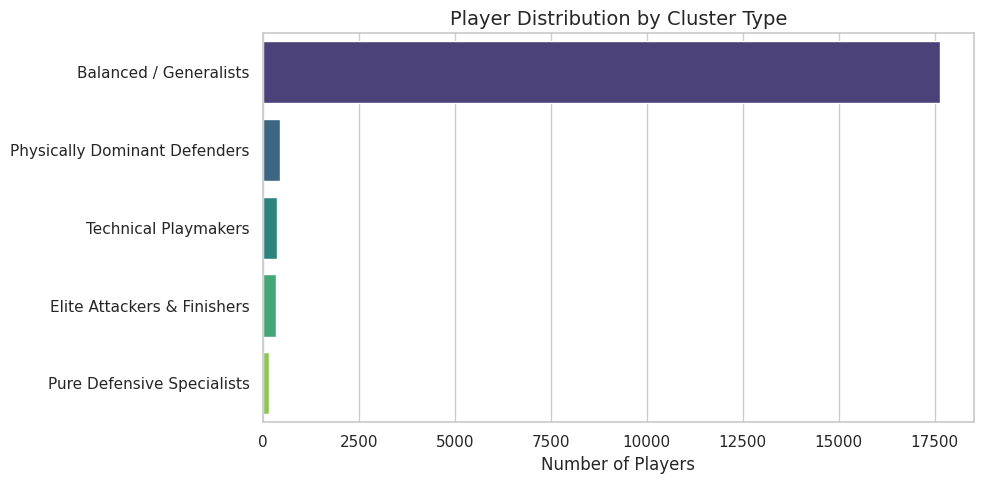

In [ ]:
plt.figure(figsize=(10, 5))

# Create a horizontal bar chart (countplot) sorted by largest cluster to smallest
sns.countplot(
    data=cluster_df,
    y='Cluster',
    order=cluster_df['Cluster'].value_counts().index,
    palette='viridis'
)

plt.title('Player Distribution by Cluster Type', fontsize=14)
plt.xlabel('Number of Players')
plt.ylabel('')
plt.tight_layout()
plt.show()

### Cluster Profile Breakdown

Based on the average stats calculated above, we can refine our player type definitions:
*   **High DEF / Low SHO:** Pure defensive specialists.
*   **High PAC / High DRI / High SHO:** Elite attackers and finishers.
*   **High PAS / High DRI / Balanced:** Technical playmakers and creative midfielders.
*   **High PHY / High DEF:** Physically dominant defenders.
*   **Low Outfield Stats:** Likely capturing the specialized Goalkeeper profiles.

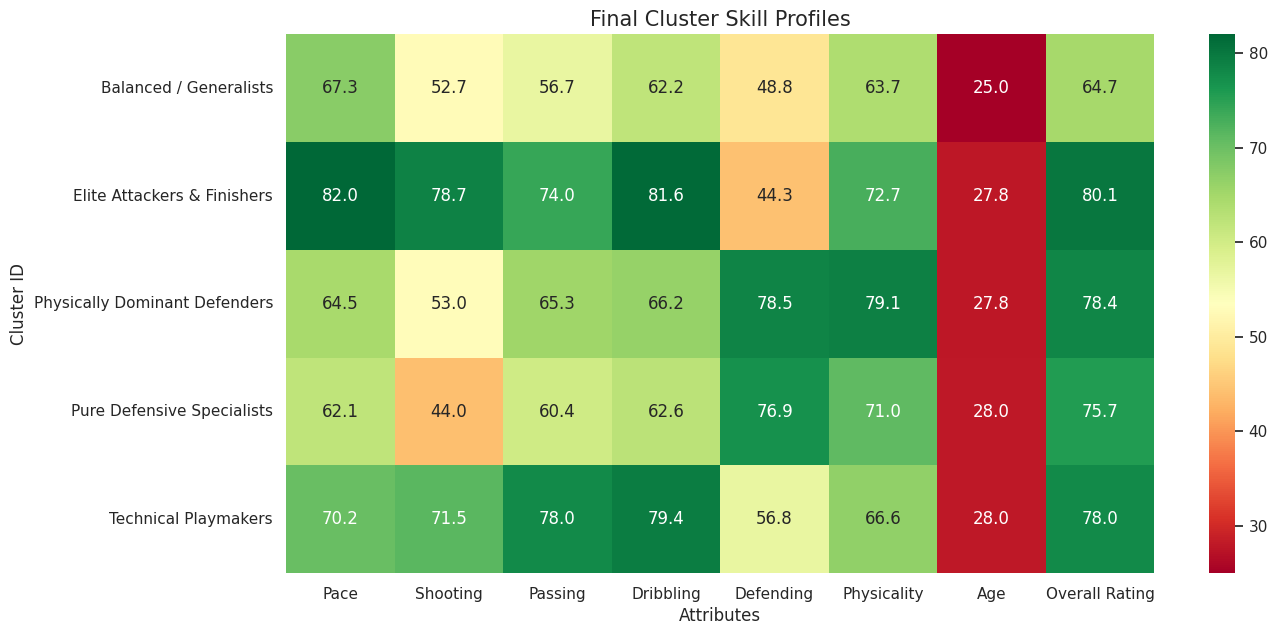

In [ ]:
# Map the abbreviations to their full names for the final report
full_name_map = {
    'PAC': 'Pace',
    'SHO': 'Shooting',
    'PAS': 'Passing',
    'DRI': 'Dribbling',
    'DEF': 'Defending',
    'PHY': 'Physicality',
    'Age': 'Age',
    'OVA': 'Overall Rating'
}

# Re-prepare the summary with full names
final_cluster_summary = cluster_df.groupby('Cluster')[cluster_features].mean()
final_cluster_summary.rename(columns=full_name_map, inplace=True)

# Visualize the profile of each cluster using the full names
plt.figure(figsize=(14, 7))
sns.heatmap(final_cluster_summary, annot=True, cmap='RdYlGn', fmt='.1f')
plt.title('Final Cluster Skill Profiles', fontsize=15)
plt.ylabel('Cluster ID')
plt.xlabel('Attributes')
plt.show()

**Key Points**

* Offensive Dominance: "Elite Attackers & Finishers" boast the highest attacking stats by a wide margin (Pace: 82.0, Shooting: 78.7, Dribbling: 81.6) but have a glaring weakness in Defending (44.3).

* Defensive Anchors: Both defensive clusters show dark green for Defending and Physicality (all 71.0 or higher) while glowing bright red/orange for Shooting (44.0 to 53.0).

* Balanced" Actually Means "Average"
The "Balanced / Generalists" cluster does not represent well-rounded elite players (like a prime Ruud Gullit). Instead, they are statistically the weakest group across the board. Every one of their core stats hovers in the mediocre 48 to 67 range, resulting in the lowest Overall Rating (64.7) of any group.

* Technical Playmakers Are the Most Well-Rounded Elites
If you are looking for players who can do a bit of everything at a high level, the "Technical Playmakers" are it. They have elite Passing (78.0) and Dribbling (79.4), strong Pace (70.2) and Shooting (71.5), and are significantly better at Defending (56.8) than the elite attackers.

* Age Uniformity Among Specialists
Age is almost completely irrelevant when distinguishing between the specialized roles. "Elite Attackers," "Physically Dominant Defenders," "Pure Defensive Specialists," and "Technical Playmakers" all perfectly average out to between 27.8 and 28.0 years old, indicating this is the statistical "peak" for elite players in this dataset. The only outlier is the "Balanced / Generalists" group, which skews younger at exactly 25.0 years old.

* Attackers Hold the Highest Overall Value
The "Elite Attackers & Finishers" are the highest-rated group in the dataset, boasting an average Overall Rating of 80.1. In standard FIFA/EA FC mechanics, attacking attributes (Pace, Shooting, Dribbling) are heavily weighted in calculating overall ratings for forwards, which is clearly reflected in this top-tier cluster.

**Problem Statement**
* Identify and visualize the top 10 clubs that maximize return on investment, calculated as the overall squad value generated per million spent.

In [ ]:
# 1. Sort the dataset so the highest-paid players are at the top for each club
df_sorted = df.sort_values(by=['Club', 'Wage in Euros'], ascending=[True, False])

# 2. Extract only the top 15 highest-paid players PER club
top_15_per_club = df_sorted.groupby('Club').head(15)

# 3. Aggregate the data to create the 'club_efficiency' dataframe
club_efficiency = top_15_per_club.groupby('Club').agg(
    Total_Top15_Wage=('Wage in Euros', 'sum'),
    Median_Top15_OVA=('OVA', 'median')
).reset_index()

/tmp/ipykernel_894/3157738538.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




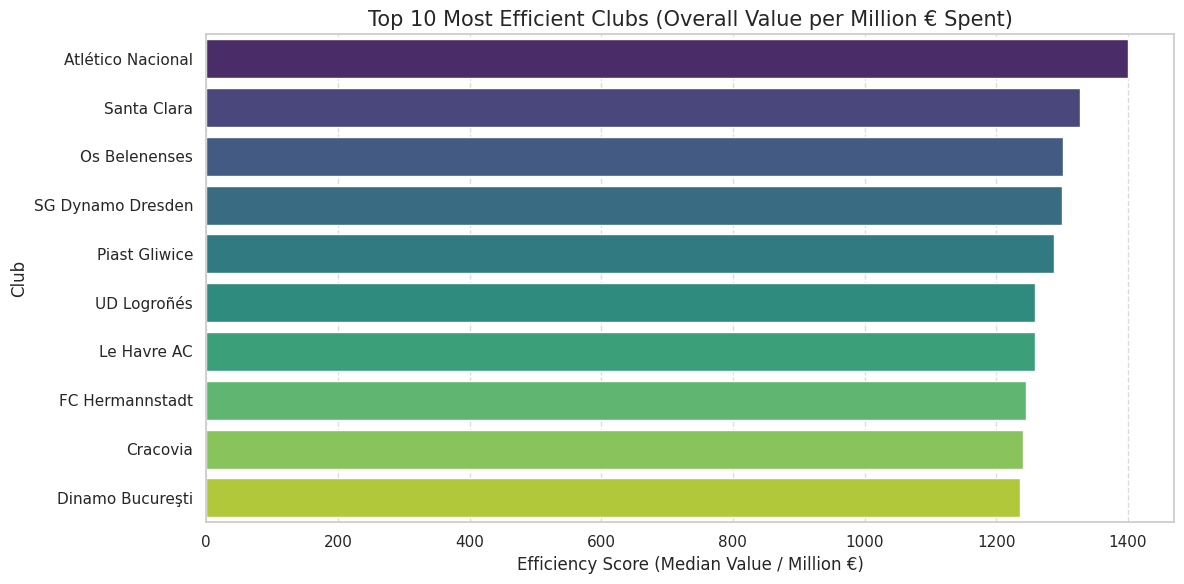

,Club,Median_Top15_OVA,Total_Top15_Wage,OVA_Per_Million_Wage
66,Atlético Nacional,70.00,50000.00,1400.00
545,Santa Clara,69.00,52000.00,1326.92
441,Os Belenenses,69.00,53000.00,1301.89
520,SG Dynamo Dresden,65.00,50000.00,1300.00
460,Piast Gliwice,67.00,52000.00,1288.46
621,UD Logroñés,68.00,54000.00,1259.26
364,Le Havre AC,68.00,54000.00,1259.26
227,FC Hermannstadt,66.00,53000.00,1245.28
167,Cracovia,67.00,54000.00,1240.74
191,Dinamo Bucureşti,68.00,55000.00,1236.36


In [ ]:

most_efficient = club_efficiency[club_efficiency['Total_Top15_Wage'] >= 50000].sort_values(by='OVA_Per_Million_Wage', ascending=False).head(10)
plt.figure(figsize=(12, 6))

# Fix: Explicitly pass the dataframe, put the score on X and the Club on Y
sns.barplot(
    data=most_efficient,
    x='OVA_Per_Million_Wage',
    y='Club',
    palette='viridis'
)

# 3. Formatting
plt.title('Top 10 Most Efficient Clubs (Overall Value per Million € Spent)', fontsize=15)
plt.xlabel('Efficiency Score (Median Value / Million €)', fontsize=12)
plt.ylabel('Club', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Display the dataframe cleanly
display(most_efficient[['Club', 'Median_Top15_OVA', 'Total_Top15_Wage', 'OVA_Per_Million_Wage']])

**Top 10 Most Efficient Clubs**
* Atlético Nacional: Leads the pack with an efficiency score of 1400.00, achieving a median Overall Value of 70 for a total wage spend of only €50,000.
* Santa Clara: Follows closely with a score of 1326.92.
* Os Belenenses: Rounds out the top three at 1301.89.

**Key Insights**
* Efficiency Leaders: The most efficient clubs are primarily found in leagues outside the 'Big 5' European leagues (such as the Portuguese Primeira Liga, Colombian Categoría Primera A, and German 3. Liga).
* Quality at Low Cost: These clubs successfully maintain professional-grade squads (Values at 65-70) while keeping their core wage commitments remarkably low (approx. €50k-€55k for their top 15 earners).


In [ ]:
top_countries = df['Nationality'].value_counts().head(10)
display(top_countries)

,count
Nationality,
England,1705
Germany,1195
Spain,1065
France,1003
Argentina,943
Brazil,887
Japan,485
Netherlands,438
Italy,387


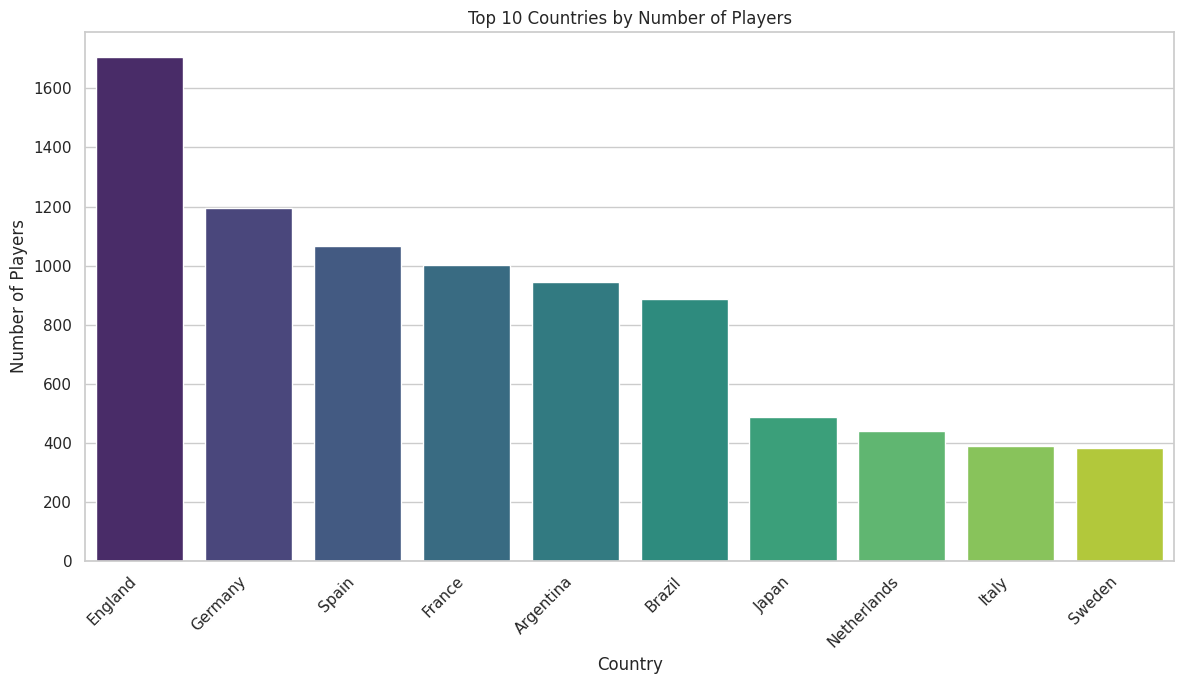

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x=top_countries.index, y=top_countries.values, hue=top_countries.index, palette='viridis', legend=False)
plt.title('Top 10 Countries by Number of Players')
plt.xlabel('Country')
plt.ylabel('Number of Players')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Get the top 20 most popular clubs by player count
top_20_clubs = df['Club'].value_counts().head(20).index.tolist()

# Filter the DataFrame to include only players from these top 20 clubs
df_top_clubs = df[df['Club'].isin(top_20_clubs)]

# Calculate the average OVA and Age for these clubs
average_stats_top_clubs = df_top_clubs.groupby('Club')[['OVA', 'Age']].mean().sort_values(by='OVA', ascending=False)

# Display the results
display(average_stats_top_clubs)

,OVA,Age
Club,,
Chelsea,77.85,25.12
Manchester United,77.74,25.21
Tottenham Hotspur,76.52,24.91
Liverpool,76.02,24.58
FC Barcelona,75.77,24.24
Arsenal,75.71,24.76
Everton,74.23,24.97
Leicester City,74.09,25.73
Real Betis,73.73,25.94


Problem Statement: Can we build a model to accurately predict a player's Values in Euro Million based on their physical attributes, skill ratings, and potential, and serve these predictions in real-time?

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Select the core features and the target variable
features = ['Age', 'OVA', 'POT', 'PAC', 'SHO', 'PAS', 'DRI', 'DEF', 'PHY', 'Contract Type', 'BOV', 'Volleys', 'Skill', 'Dribbling', 'Curve', 'Ball Control', 'Acceleration', 'Sprint Speed', 'Agility', 'Long Shots', 'Positioning', 'Defending', 'Marking', 'Standing Tackle', 'Sliding Tackle', 'Total Stats']
target = 'Values in Euro Million'

# Create a clean working copy of the data
ml_df = df[features + [target]].copy()

# 2. Handle missing values (if any exist in your cleaned dataset)
# XGBoost can handle NaNs internally, but it's best practice to be explicit.
# We'll fill missing base stats with the median.
numeric_cols = ml_df.select_dtypes(include=['float64', 'int64']).columns
ml_df[numeric_cols] = ml_df[numeric_cols].fillna(ml_df[numeric_cols].median())

# 3. One-Hot Encode Categorical Variables
# This turns 'Contract Type' into binary columns (e.g., Contract Type_On Loan: 0 or 1)
X = pd.get_dummies(ml_df[features], drop_first=True)
y = ml_df[target]

# 4. Perform the 3-Way Data Split
# First, split off 70% for Training, leaving 30% for Val/Test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# Second, split the remaining 85% into Training and Validation
# 0.176 of 0.85 is roughly 0.15 of the total dataset
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, random_state=42)

print(f"Training shapes: X={X_train.shape}, y={y_train.shape}")
print(f"Validation shapes: X={X_val.shape}, y={y_val.shape}")
print(f"Testing shapes: X={X_test.shape}, y={y_test.shape}")

Training shapes: X=(13292, 27), y=(13292,)
Validation shapes: X=(2840, 27), y=(2840,)
Testing shapes: X=(2847, 27), y=(2847,)


In [ ]:

from sklearn.linear_model import LinearRegression
# Initialize the model with baseline hyperparameters
# You can adjust n_estimators (number of trees) and learning_rate to tune performance
model = LinearRegression()

# Train the model on the Training Set only
model.fit(X_train, y_train)
print("Model training complete.")

Model training complete.


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict on the Validation Set
val_predictions = model.predict(X_val)

# Calculate Validation Metrics
val_mae = mean_absolute_error(y_val, val_predictions)
val_rmse = np.sqrt(mean_squared_error(y_val, val_predictions))
val_r2 = r2_score(y_val, val_predictions)

print("--- VALIDATION RESULTS ---")
print(f"Mean Absolute Error (MAE): €{val_mae:.2f}M")
print(f"Root Mean Squared Error (RMSE): €{val_rmse:.2f}M")
print(f"R-Squared (R²): {val_r2:.4f}")

--- VALIDATION RESULTS ---
Mean Absolute Error (MAE): €428050.86M
Root Mean Squared Error (RMSE): €542289.45M
R-Squared (R²): 0.8398


In [ ]:
# Predict on the strictly isolated Test Set
test_predictions = model.predict(X_test)

# Calculate Final Testing Metrics
test_mae = mean_absolute_error(y_test, test_predictions)
test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
test_r2 = r2_score(y_test, test_predictions)

print("--- FINAL TESTING RESULTS ---")
print(f"Mean Absolute Error (MAE): €{test_mae:.2f}M")
print(f"Root Mean Squared Error (RMSE): €{test_rmse:.2f}M")
print(f"R-Squared (R²): {test_r2:.4f}")

results_df = pd.DataFrame({
    'Actual Value (€M)': y_test.values,
    'Predicted Value (€M)': np.round(test_predictions, 2)
})

# This forces Pandas to display standard numbers with 2 decimal places
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("\nSample Predictions:")
print(results_df.head(10))

--- FINAL TESTING RESULTS ---
Mean Absolute Error (MAE): €428764.63M
Root Mean Squared Error (RMSE): €545839.96M
R-Squared (R²): 0.8315

Sample Predictions:
   Actual Value (€M)  Predicted Value (€M)
0          575000.00            1222497.27
1         1400000.00            1693095.91
2         1600000.00            1799172.82
3          400000.00             163687.06
4          130000.00            -290038.26
5         3200000.00            2401209.60
6          230000.00             -78755.50
7          150000.00            -426526.12
8         4287500.00            2988445.31
9          500000.00             630904.44


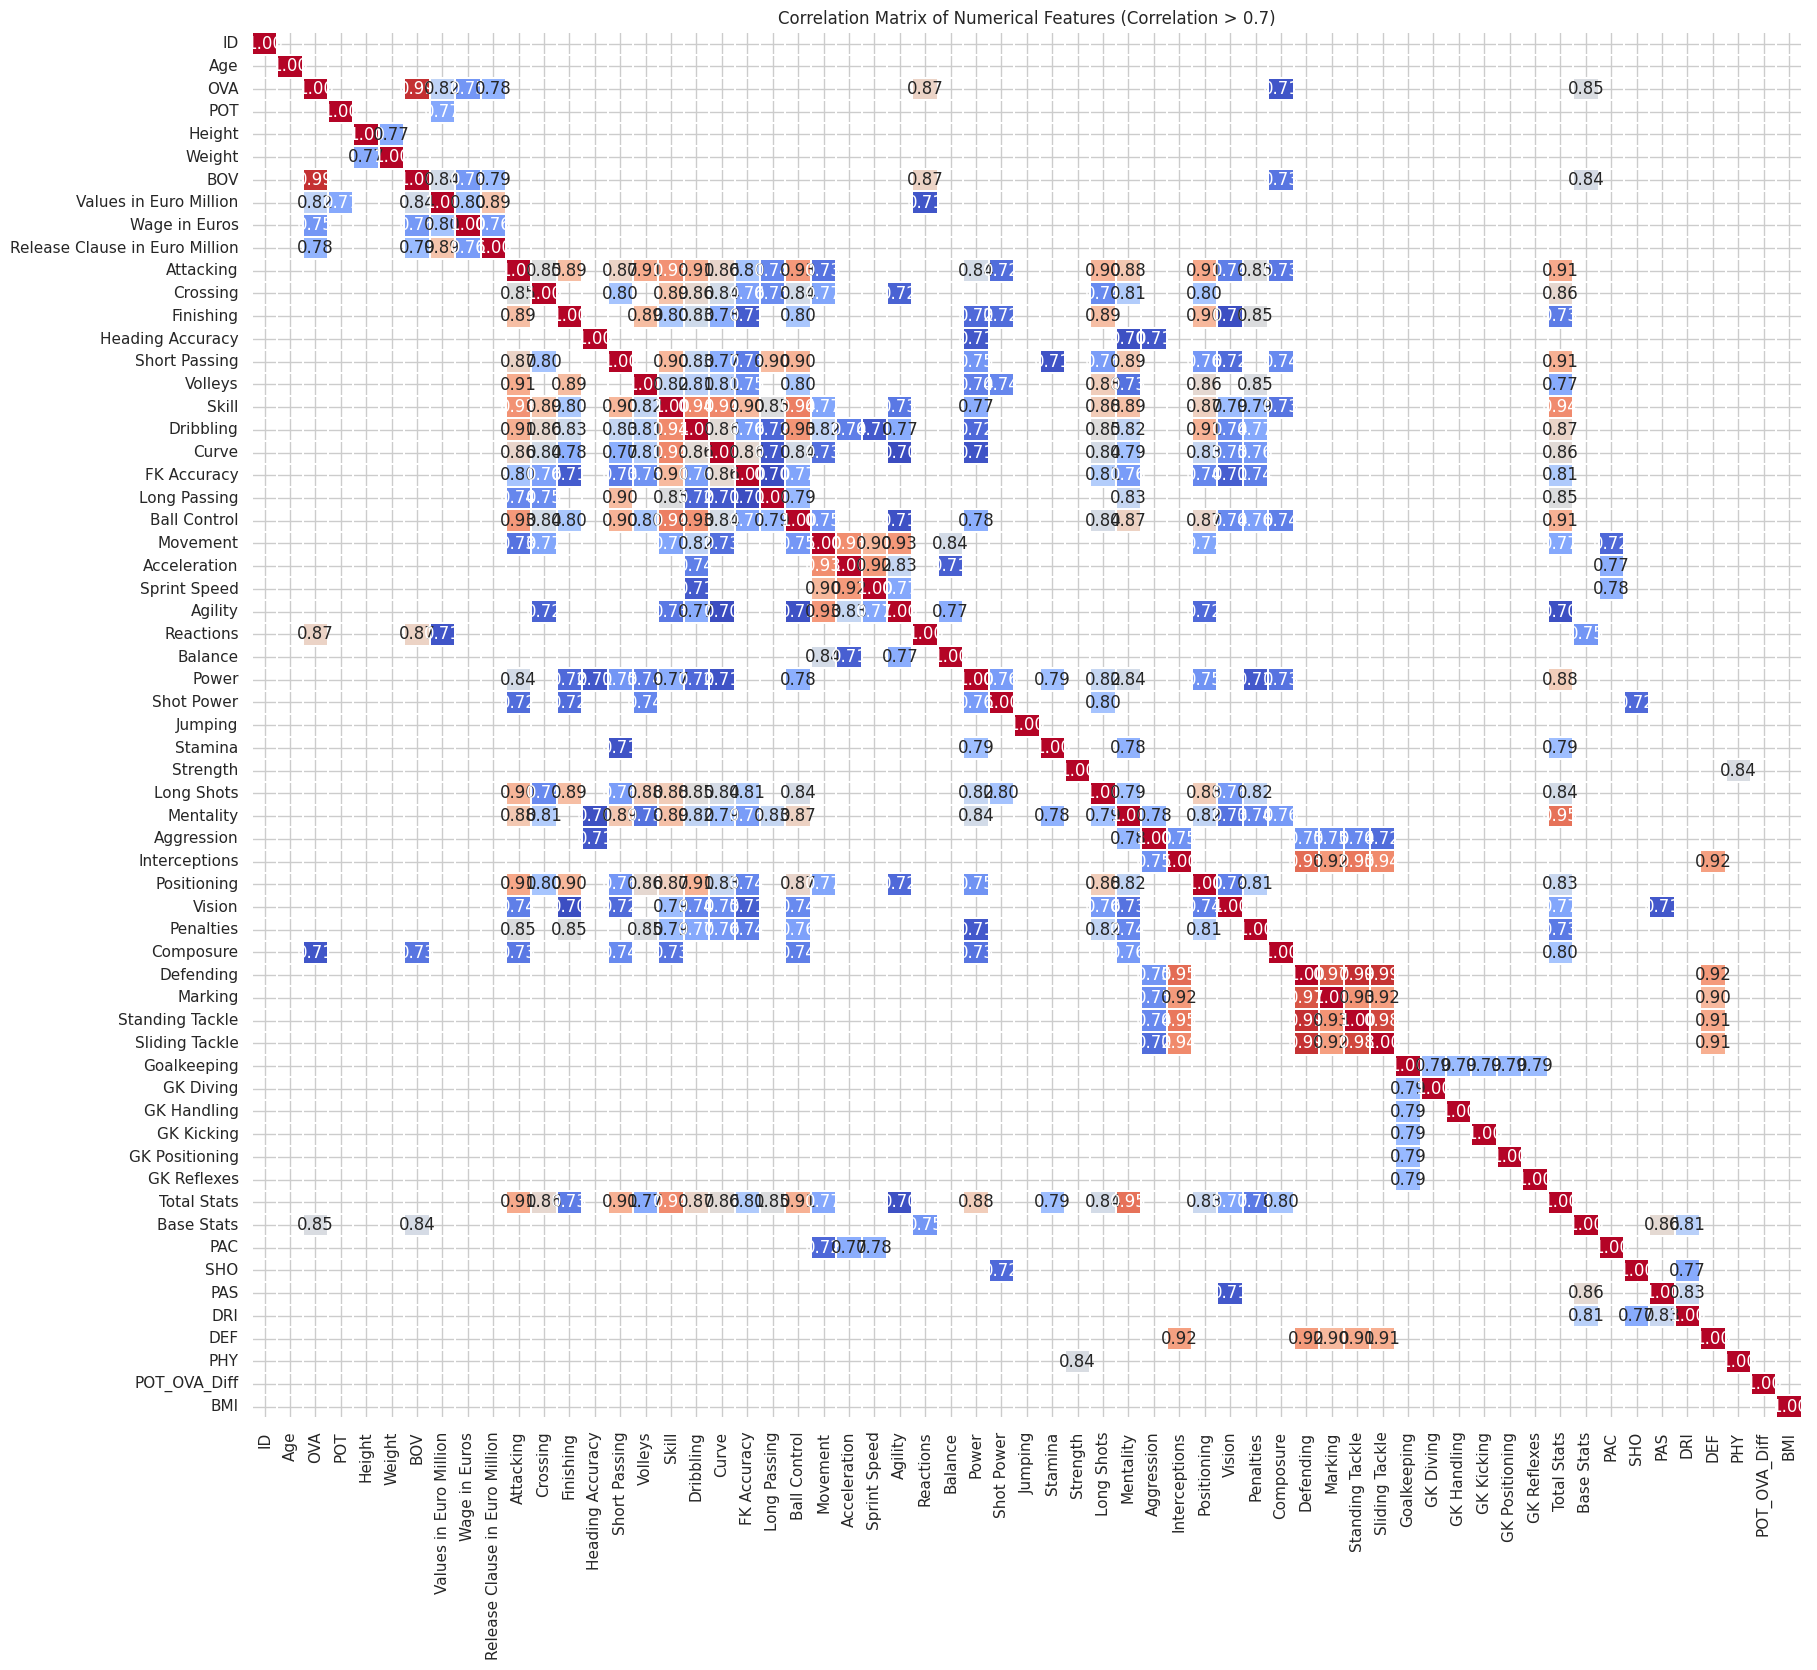

In [ ]:
# Select only numerical columns for correlation calculation
numerical_df = df.select_dtypes(include=[np.number])

# Calculate the correlation matrix
corr_matrix = numerical_df.corr()

# Plotting the heatmap for correlations > 0.9
plt.figure(figsize=(20, 18)) # Adjust figure size for better readability
sns.heatmap(corr_matrix[corr_matrix > 0.7], annot=True, cmap='coolwarm', fmt=".2f", linewidths=.05, cbar=False)
plt.title('Correlation Matrix of Numerical Features (Correlation > 0.7)')
plt.show()

The heatmap above visualizes the correlation matrix for all numerical features. Highly correlated features (values close to 1 or -1) indicate a strong linear relationship. You can examine this heatmap to identify features that might be redundant and consider removing one of them to reduce multicollinearity, especially if you plan to build linear models.

For example, if two features have a correlation coefficient very close to 1, they carry almost the same information, and one can often be dropped without significant loss of information for many models. Similarly, a strong negative correlation (close to -1) also indicates a strong relationship.

In [ ]:
import numpy as np

# Set the correlation threshold
threshold = 0.9

# Create a copy of the correlation matrix to avoid modifying the original during iteration
corr_matrix_abs = corr_matrix.abs()

# Select upper triangle of correlation matrix
uppertri_corr = corr_matrix_abs.where(np.triu(np.ones(corr_matrix_abs.shape), k=1).astype(bool))

# Find features with correlation greater than the threshold
to_drop_high_corr = [column for column in uppertri_corr.columns if any(uppertri_corr[column] > threshold)]

print(f"Features to consider dropping due to high correlation (> {threshold}):")
for feature in to_drop_high_corr:
    correlated_features = corr_matrix_abs.index[corr_matrix_abs[feature] > threshold].tolist()
    correlated_features.remove(feature) # Remove itself from the list
    print(f"- '{feature}' is highly correlated with: {correlated_features}")

# Display the list of features to drop
print(f"\nSuggested features to drop: {to_drop_high_corr}")

Features to consider dropping due to high correlation (> 0.9):
- 'BOV' is highly correlated with: ['OVA']
- 'Volleys' is highly correlated with: ['Attacking']
- 'Skill' is highly correlated with: ['Attacking', 'Short Passing', 'Dribbling', 'Curve', 'Ball Control', 'Total Stats']
- 'Dribbling' is highly correlated with: ['Attacking', 'Skill', 'Ball Control', 'Positioning']
- 'Curve' is highly correlated with: ['Skill']
- 'Ball Control' is highly correlated with: ['Attacking', 'Short Passing', 'Skill', 'Dribbling', 'Total Stats']
- 'Acceleration' is highly correlated with: ['Movement', 'Sprint Speed']
- 'Sprint Speed' is highly correlated with: ['Acceleration']
- 'Agility' is highly correlated with: ['Movement']
- 'Long Shots' is highly correlated with: ['Attacking']
- 'Positioning' is highly correlated with: ['Attacking', 'Dribbling']
- 'Defending' is highly correlated with: ['Interceptions', 'Marking', 'Standing Tackle', 'Sliding Tackle', 'DEF']
- 'Marking' is highly correlated with: [

The code above identifies features that have a correlation greater than 0.9 with at least one other feature. For each identified feature, it lists the features it is highly correlated with.

To address multicollinearity, you can choose to remove one of the features from each highly correlated pair. The `to_drop_high_corr` list provides a starting point for features that could be considered for removal. The choice of which feature to remove (e.g., the one that is less relevant to the target variable or has more missing values) often depends on domain knowledge or further analysis.

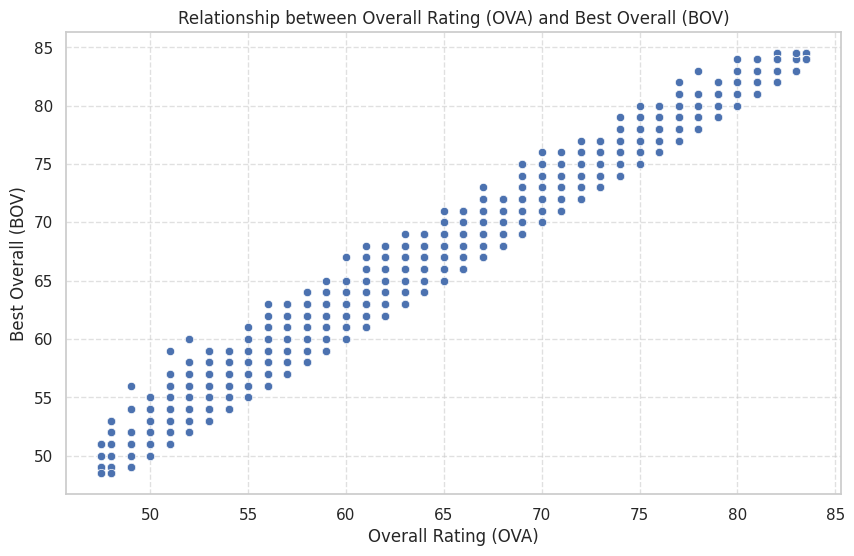

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='OVA', y='BOV', data=df)
plt.title('Relationship between Overall Rating (OVA) and Best Overall (BOV)')
plt.xlabel('Overall Rating (OVA)')
plt.ylabel('Best Overall (BOV)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

##Train a Model to Predict players Values  

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Select the core features and the target variable
#  to avoid collinearity with granular stats
features = ['Age', 'OVA', 'POT', 'PAC', 'SHO', 'PAS', 'DRI', 'DEF', 'PHY', 'Contract Type']
target = 'Values in Euro Million'

# Create a clean working copy of the data
ml_df = df[features + [target]].copy()

# 2. Handle missing values (if any exist in your cleaned dataset)
# XGBoost can handle NaNs internally, but it's best practice to be explicit.
# We'll fill missing base stats with the median.
numeric_cols = ml_df.select_dtypes(include=['float64', 'int64']).columns
ml_df[numeric_cols] = ml_df[numeric_cols].fillna(ml_df[numeric_cols].median())

# 3. One-Hot Encode Categorical Variables
# This turns 'Contract Type' into binary columns (e.g., Contract Type_On Loan: 0 or 1)
X = pd.get_dummies(ml_df[features], drop_first=True)
y = ml_df[target]

# 4. Perform the 3-Way Data Split
# First, split off 70% for Training, leaving 30% for Val/Test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# Second, split the remaining 85% into Training and Validation
# 0.176 of 0.85 is roughly 0.15 of the total dataset
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, random_state=42)

print(f"Training shapes: X={X_train.shape}, y={y_train.shape}")
print(f"Validation shapes: X={X_val.shape}, y={y_val.shape}")
print(f"Testing shapes: X={X_test.shape}, y={y_test.shape}")

Training shapes: X=(13292, 11), y=(13292,)
Validation shapes: X=(2840, 11), y=(2840,)
Testing shapes: X=(2847, 11), y=(2847,)


In [ ]:
from xgboost import XGBRegressor

# Initialize the model with baseline hyperparameters
# You can adjust n_estimators (number of trees) and learning_rate to tune performance
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1 # Uses all available CPU cores for faster training
)

# Train the model on the Training Set only
model.fit(X_train, y_train)
print("Model training complete.")

Model training complete.


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict on the Validation Set
val_predictions = model.predict(X_val)

# Calculate Validation Metrics
val_mae = mean_absolute_error(y_val, val_predictions)
val_rmse = np.sqrt(mean_squared_error(y_val, val_predictions))
val_r2 = r2_score(y_val, val_predictions)

print("--- VALIDATION RESULTS ---")
print(f"Mean Absolute Error (MAE): €{val_mae:.2f}M")
print(f"Root Mean Squared Error (RMSE): €{val_rmse:.2f}M")
print(f"R-Squared (R²): {val_r2:.4f}")

--- VALIDATION RESULTS ---
Mean Absolute Error (MAE): €50535.05M
Root Mean Squared Error (RMSE): €105983.77M
R-Squared (R²): 0.9939


In [ ]:
# Predict on the strictly isolated Test Set
test_predictions = model.predict(X_test)

# Calculate Final Testing Metrics
test_mae = mean_absolute_error(y_test, test_predictions)
test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
test_r2 = r2_score(y_test, test_predictions)

print("--- FINAL TESTING RESULTS ---")
print(f"Mean Absolute Error (MAE): €{test_mae:.2f}M")
print(f"Root Mean Squared Error (RMSE): €{test_rmse:.2f}M")
print(f"R-Squared (R²): {test_r2:.4f}")

# Optional: View a side-by-side comparison of a few actual vs predicted values
results_df = pd.DataFrame({
    'Actual Value (€M)': y_test.values,
    'Predicted Value (€M)': np.round(test_predictions, 2)
})

# This forces Pandas to display standard numbers with 2 decimal places
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("\nSample Predictions:")
print(results_df.head(10))

--- FINAL TESTING RESULTS ---
Mean Absolute Error (MAE): €47934.37M
Root Mean Squared Error (RMSE): €94314.09M
R-Squared (R²): 0.9950

Sample Predictions:
   Actual Value (€M)  Predicted Value (€M)
0          575000.00             590700.25
1         1400000.00            1461597.62
2         1600000.00            1507369.50
3          400000.00             344448.88
4          130000.00             137258.86
5         3200000.00            3649756.75
6          230000.00             245203.72
7          150000.00             135865.08
8         4287500.00            4225911.50
9          500000.00             491621.84
